In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
def optimizar_w_tres_series(series, w_min, w_max, labels=None):
    """
    Grafica la entropía vs w para múltiples series y marca el w óptimo de cada una.

    Parámetros:
        series (list): Lista de series (ej: [x1, x2, x3]).
        w_min (int): Valor mínimo de w.
        w_max (int): Valor máximo de w (exclusive).
        labels (list): Nombres de cada serie (opcional).

    Retorna:
        w_optimos (list): Lista de w óptimos para cada serie.
    """
    valores_w = list(range(w_min, w_max))
    w_optimos = []

    plt.figure(figsize=(8, 5))

    for i, x in enumerate(series):
        entropias = []

        for w in valores_w:
            patrones = obtener_patrones(x, w)

            if len(patrones) < w + 1:
                entropias.append(0.0)
                continue

            G, _ = construir_grafo(patrones, w)
            ent = calcular_entropia_red(G)
            entropias.append(ent)

        # Encontrar óptimo de esta serie
        idx_opt = np.argmax(entropias)
        w_opt = valores_w[idx_opt]
        w_optimos.append(w_opt)

        label = labels[i] if labels else f'Serie {i+1}'

        # Graficar curva
        plt.plot(valores_w, entropias, marker='o', linestyle='-', label=label)

        # Línea vertical del óptimo
        plt.axvline(x=w_opt, linestyle='--',
                    label=f'$w_{{opt}}$ {label} = {w_opt}')

    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red (bits)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 12
    })

    plt.show()

    return w_optimos

BOLIVAR

In [4]:
w_opt=4
serie_bolivar =  [
    -0.9613063168, -1.157069067, -1.386790481, -1.082572836, -0.3566588477,
    -0.03235249128, -0.3303903953, -0.0311025804, 0.4802647777, 1.010683803,
    1.999092312, 0.8282382911, 0.241654541, -0.6401360909, -0.6950316815,
    -0.8018833662, -0.08959279246, 0.9130188312, 0.6743444, 0.2169361203,
    0.4230544561, 1.054754997, 0.3121784033, 0.05587837495, 0.1108785632,
    0.3625993023, 0.2500591044, 0.3583909918, 0.8215825476, 0.2237592879,
    -0.7229034197, -1.340539789, -1.379640263, -1.327333796, -0.7562873894,
    0.3688427284, 0.1572118099, 2.343634487, 0.9462395457, 0.5120902253,
    -0.007065280103, -0.05251399241, 0.5199884324, 0.6457409911, 0.218037242,
    -0.3371499784, 0.1964859487, 0.5886806772, 0.08409728942, -0.4557310001,
    -1.022548987, 0.2111817951, -0.4007693785, -0.1953654509, 0.09182639044,
    -0.1400945447, 0.0928412732, 1.024837025, 0.987131064, -0.3155459656,
    0.5403128725, -0.04162939494, 0.4359435108, -0.8664878921, -1.362269903,
    -0.9076463719, -0.6603025737, -0.3650474997, -0.6394518296, -0.103970068,
    0.252553523, 1.373431599, 1.033046802, 1.322458673, 1.205888163,
    0.3757717172, -1.122614909, -2.229759315, -2.020212382, -1.891566497,
    -2.039800327, -1.952661296, -2.459289184, -2.134593588, -1.832082528,
    -1.506750987, -1.165761043, 0.2041925247, 0.8345474345, 0.8731396751,
    0.809549436, 0.4507706371, 0.3153406517, -0.1824068697, -0.3620418708,
    1.025380331, 0.7865587724, -0.00164575336, 1.266124255, 0.5685590925,
    1.160411447, 1.714768245, 0.9917129885, 0.2322228714, -0.616949399,
    -0.3530194323, 0.7601343194, 1.90431709, 2.093557572, 1.342929463,
    1.51166573, 3.137245398, 2.486834697, 1.266567398, 0.3294024336,
    0.5254813065, 0.5670887516, 0.3506629274, -0.3455477875, -1.080661773,
    -0.7978506129, -0.4813062258, 0.6828886814, 0.03891846774, 0.01153525545,
    0.1874727731, -0.9912596759, -1.383693624, -0.6423515511, 0.2226374965,
    -0.3561950875, -0.2279843184, -0.4077027113, -0.6228481136, -0.6207761776,
    -0.5634808318, -0.8802530673, -1.285702782, -1.152227489, -0.5325973285,
    -0.04845604035, 0.2532929476, 0.9092457563, -0.1730248311, -0.5037590204,
    0.3897000677, 0.1236387581, -0.3736518777, -1.195077385, -1.141055003,
    -0.8662246313, -0.6282511627, -0.09012227664, -1.559398383, -1.510904011,
    -0.8124968138, -0.6588344426, -1.090482859, -1.255439654, -0.7282186749,
    0.3713482613, 0.3687504197, 0.7291218292, 0.7725547181, 0.6258327695,
    0.5312086937, 0.06317313562, 0.5462159542, 1.588890107, 0.6763989881,
    1.126298615, 0.5941124568, 0.3023212154, 0.1511569477, 0.7636088195,
    1.048686038, -0.3356961397, -0.4347657844, 0.2747035998, -0.8541096211,
    -0.4602275602, -0.01974711607, -0.7447751488, -0.628122338, 0.4505271947,
    0.7100932177, 2.037933962, 2.272045621, 2.679456959, 1.948761548,
    0.1973414254, -0.7379924136, -1.014445137, -0.4203743724, -0.6576231904,
    -0.956044853, -1.02480649, -0.5643313897, -0.2039681242, 0.148454723,
    0.3905509452, -0.1461338322, -0.1617741575, -0.3545757207
]
serie_niño_bolivar = [
0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27,
0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45,
0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71,
-0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32,
-0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99,
-0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35,
0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69,
-1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38,
-0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02,
0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39,
-0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06,
-0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21,
2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74,
-0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97,
-0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89,
0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35, 0.04, 0.03, 0.48, 0.52, 0.52
]

TIMBUES

In [5]:

w_opt=4
serie_timbues =[
    -1.098342295, -0.7263712684, -0.2082966367, 0.2997729425, 0.08720261098,
    -0.3923660268, -0.4109375264, -0.7184492257, -1.094889783, -0.7584700708,
    -0.6395014836, -0.6613836449, -0.4360540475, -0.1847762812, 0.5026179488,
    1.056794688, 0.3995191011, -0.9135015839, -1.418730715, -1.381957032,
    -1.40638842, -1.509720596, -1.263008861, -0.8997605967, -1.338568578,
    -1.643874879, -0.8149070459, -0.2346063144, -0.779300134, -1.07079741,
    -0.9247239273, -1.052001543, -1.033041129, -0.490250981, -0.04499216921,
    -0.6037071474, -1.321685132, -1.833954403, -2.325660457, -2.244841703,
    -1.506674608, -1.106170038, -1.133722371, -1.473854828, -1.24023863,
    -0.7301123922, 0.05570440091, 0.08188208743, -0.4317485268, -0.7748902665,
    -1.03280088, -1.382091304, -0.9788189536, 0.4197875723, 1.049484142,
    0.6928774938, -0.0797289982, -0.05958420689, -0.4423244607, -1.309291382,
    -1.474527603, -1.518698347, -2.164484139, -1.407587784, -0.8719854516,
    -0.503772707, 0.3561039155, 0.06252721278, -0.7660956893, -1.358084521,
    -1.582686154, -1.518210878, -1.120789054, -1.439613907, -1.981453937,
    -1.252945468, 0.005308961433, 0.6771674172, 0.9448294928, 1.295227293,
    1.355819624, 0.5030753814, -0.286499705, -0.9183969467, -1.146912438,
    -0.6177849486, -0.08491476645, 0.1783420141, 0.0847286846, -0.1117057158,
    0.03039654133, 0.8237091803, 1.676932576, 1.906513434, 1.22323799,
    0.3474200165, -0.3538863304, -0.5663922358, -0.2034347692, -0.1444938966,
    -0.2729074623, -0.454353627, -0.6689705299, -0.6593754737, -0.117722295,
    0.1887050491, 0.1126587536, 0.5821057687, 0.7811867857, 0.9588285337,
    1.1231018, 1.29605721, 1.2293275, 0.8055397676, 0.2611663755,
    -0.0142210246, -0.03922257632, 0.02529343815, -0.1097169242, -0.1502306461,
    0.005854432683, -0.0002971594942, 0.1565762445, -0.01151928637,
    -0.6374706031, -1.058387675, -1.003416395, -0.668022156, -0.3385035591,
    -0.1558205546, 0.3689227001, 0.1681864232, -0.01237146511, 0.3186183487,
    0.4510684584, 1.249896823, 1.795522327, 1.44757252, 0.7508211873,
    -0.0757363328, -0.4032777482, -0.2552352548, -0.1773709002, -0.1233582317,
    -0.4218192222, -0.5093456562, -0.1074026154, 0.1214696638, -0.5686553319,
    -1.139783807, -1.368763588, -1.429537604, -1.23976178, -0.5678340463,
    -0.5941904783, -0.9655649474, -0.3577927438, 0.2856040442, 0.2062494649,
    -0.2755039298, -0.7308245494, -0.9794710477, -1.160202645, -1.269157132,
    -1.281337891, -1.489022226, -0.474276257, 0.1094037682, -1.004116701,
    -1.657682076, -1.147499866, -0.9563660556, -0.7264383448, -1.074693773,
    -1.523604114, -1.421141033, -1.13323105, -1.336383146, -1.381734235,
    -1.119489175, -0.6941328691, -0.3675903673, 0.1456764717, 0.8897052716,
    1.041081761, 1.122549852, 1.257619098, 1.014924722, 0.3766416366,
    0.3834442746, 0.977857509, 1.099631197, 1.55189917, 2.056935092,
    2.488834607, 2.383228255, 1.451873894, 0.461560497, -0.3471085521,
    -0.7554179607, -0.8740698549, -0.6218399881, -0.2978243923, -0.3981301716,
    -0.2373228248, 0.1865744969, 0.3293437317, 0.5156613018, -0.5168098585,
    -1.169525641, -0.8512354094, -0.7072061567, -0.7089510903, -0.9810589594,
    -1.295499928, -1.171719049, -0.9019694335, -0.7831104273, -1.043907851,
    -1.824909805, -2.121037451, -1.934214449, -1.828783519, -1.503451254,
    -1.430256665, -1.515282713, -1.328959231, -1.304626283, -0.81004173,
    -0.7868529396, -1.772818194, -2.09457308, -1.67629235, -0.9111197943,
    -0.5632566696, -1.217038838, -1.593236051, -1.110290254, -0.2679806547,
    -0.2176942332, -0.8468079737, -1.137673365, -0.8169202699, -1.294746502,
    -1.776626781, -1.424401553, -0.9691186828, -1.114469654, -1.204603804,
    -0.5241707765, -0.879869197, -1.348379624, -0.4228835082, 0.3407660016,
    -0.2107070273, -0.8069434913, -0.5183477046, -0.2106171614, -0.107853517,
    -0.1648829121, -0.7647682437, -1.011422647, -1.273438849, -1.296101656,
    -1.215679827, -1.355086594, -0.6460564434, -0.4868034964, -1.175328944,
    -1.030111558, -0.4379704325, -0.1908586889, 0.4940496873, 1.179152658,
    1.261452681, 1.381533043, 1.27905494, 1.211167422, 1.065608505,
    0.8472876186, 0.8443176921, 0.8546657042, 0.8953919719, 0.8115728591,
    0.781667192, 0.9247411652, 0.3643266419, -0.1193303754, 0.1081226422,
    0.7670381469, 0.7000097676, 0.6063903387, 0.8340876722, 0.6251222616,
    0.5706632165, 0.4574400084, 0.4128564141, -0.3044736677, -0.7769910312,
    -0.5986212274, -0.2230552292, -0.02830203382, -0.2775494218, -0.4085789199,
    -0.2558841743, -0.3794677202, -0.7187189062, -0.348797605, 0.1197100341,
    0.5859079389, 0.5333635328, 0.5121533271, 0.6222332523, 0.4233685934,
    0.3588847123, 0.1370285392, -0.6642692435, -0.4425912509, -0.02027288793,
    0.07423477288, 0.4510688038, 0.2898001079, 0.4025413335, 0.7601730872,
    0.9070506997, 1.583119675, 1.60209846, 0.860308318, 0.2733756007,
    -0.3749484272, -0.5635560118, -0.3597310131, -0.2764358125, -0.3559265065,
    -0.346089131, 0.2346280168, 0.7029859528, 0.4036669396, 0.04260311494,
    -0.6266612958, -1.495307919, -1.276742814, -0.8392271807, -0.298227615,
    0.3361738782, -0.01037184609, -0.3122253745, -0.1598494074, -0.3632472096,
    -0.2085278679, -0.2001067867, -0.4384490927, -0.2031159932, 0.3981438231,
    0.4489230336, 0.6040048453, 1.07512288, 1.414507061, 1.527901493,
    1.49302651, 1.07806211, 0.8014157952, 1.046818414, 1.113279859,
    0.5207816115, 0.3495675302, 0.4190348631, 0.6608276014, 1.002577334,
    1.020651862, 0.8610318388, 0.6578535139, 0.7296535737, 1.292486867,
    1.054830224, 0.2908964965, 0.2359457632, 0.1166773679, -0.3265920961,
    -0.2413929488, -0.1044993905, -0.2559126087, -0.3673045354, 0.1752081189,
    0.9179838195, 1.053647755, 0.7127054046, 0.7900567689, 0.9034378463,
    0.6936933725, 1.121061475, 2.085993777, 2.420959379, 1.592038894,
    0.9872702361, 2.269873743, 3.073187163, 2.909973929, 2.899231002,
    2.53243572, 2.420208798, 2.811971512, 2.916965193, 2.797987318,
    2.412401866, 2.289557024, 2.148675747, 1.826484918, 1.489287708,
    1.494756288, 0.7190052891, -0.104944239, 0.3635869919, 0.6580276005,
    0.5903276985, 0.6176418304, 0.7441378568, 0.8400328586, 0.9572426561,
    1.054471112, 0.781436472, 0.2708278039, 0.815027281, 1.174411182,
    1.549079142, 1.471170558, 1.154841094, 1.285294327, -0.7954799215,
    1.089468406, 0.06206534539, -0.561817442, -1.049723775, -1.498063928,
    -1.051522494, 0.08993605355, 1.042713215, 1.320824672, 1.278135554,
    1.107108359, 0.8463125029, 0.7404488199, 0.6672742831, 0.3768293791,
    0.1777849988, 0.1719386007, 0.1951424945, 0.4063476543, 0.9732560606,
    1.637700399, 1.776310107, 1.537644056, 0.8232175274, -0.005408926699,
    0.2235401885, 0.47043195, 0.270680235, 0.08440391241, -0.1243712176,
    -0.2021406056, -0.1353839006, 0.6866090753, 1.035081176, 1.078095525,
    1.041176359, 0.1556449719, -0.6495882992, -0.9366846166, -0.8230550452,
    -0.05889420845, 0.5157929248, 0.5674573001, 0.4624905569, 0.2073197287,
    0.1646630453, 0.7463416213, 1.620651461, 1.998841972, 1.522913238,
    0.5476465563, 0.3044834097, 1.342422673, 0.8234190286, -0.02277616861,
    0.6376579174, 1.240552257, 1.650943277, 1.993199707, 2.333558971,
    2.087333691, 1.740601403, 0.553272357, -0.2400050692, -0.4000048639,
    -0.1365208691, 0.8340876722, 0.8104499184, 0.6069411924, 0.6810627435,
    0.08816064795, 0.1003103746, -0.1678478677, -0.06060783773, 0.5637217105,
    0.4554472698, 0.3121696985, 0.6629902294, 1.648143178, 2.829511255,
    2.722173992, 2.115387732, 2.00524982, 1.679899501, 1.715506458,
    2.07270116, 1.8454486, 1.473036351, 1.163516929, 0.8862206571,
    0.4404659258, 0.407060266, 0.2550989387, 0.1783999008, 0.1499319747,
    0.9872270558, 1.670379295, 1.035558223, 0.2084436921, 0.1905041347,
    0.3889324227, -0.2718185557, -0.3732151477, 0.2289146208, 0.8883574295,
    0.8750295023, 0.2730751058, -0.08563627718, 0.4032521905, 0.543378231,
    0.1256349846, 1.031323479, 1.722679842, 1.605858082, 0.9661685959,
    0.3744724991, 0.1402781666, 0.2890083552, 0.1587085809, 0.3501757808,
    0.4294190815, -0.1501104116, -0.5646149589, -0.126500019, 0.2007986952,
    0.4422979776, 0.5937824987, -0.007725333321, -0.2455509435, -0.2508495131,
    -0.07746074168, 0.570745634, 1.303736416, 1.28262813, 1.044984584,
    1.634766344, 1.797271623, 0.3420615357, -0.749719998, -0.2050352238,
    0.6323392294, 1.25524532, 1.220613493, 1.195422176, 1.887533851,
    2.370678361, 2.374809945, 2.163690254, 2.015631101, 2.698463978,
    3.168016567, 2.428039249, 1.48852709, 1.297168628, 1.967475616,
    2.440958631, 1.963399451, 0.8132686495, 0.1404563766, 0.3857256032,
    0.4115065527, 0.3439730547, 0.2766759522, 0.111883253, 0.6343931776,
    0.6961670443, 0.2043507995, -0.1655926861, -0.6861790502, -0.7040741122,
    -0.8815230481, -1.35576292, -1.293605146, -0.9261674972, -0.2995723769,
    -0.1076334663, -0.0853878825, 0.01000755071, 0.6645052987, 1.12916134,
    1.005144613, 0.5822825134, 0.2718884415, 0.4393491207, 0.5500588189,
    0.298783484, -0.11946385, -0.41817974, -0.5940117812, -0.4480962944,
    -0.2762695596, 0.2151465978, 0.2361726076, -0.120976386, -0.5050197804,
    -0.3305457968, 0.2265392019, 0.5785664806, 0.8714987881, 0.7885374544,
    0.5076079268, 0.4385221157, 0.7709509687, 0.9408283186, 0.9093357972,
    1.388885384, 1.223716906, 0.5587539741, 0.7986152873, 1.168875951,
    0.9069855905, 0.2228990754, -0.151678371, 0.005549626247, 0.255063087,
    0.2324086996, 0.1226291357, 0.4893857191, 0.6542924493, -0.268607219,
    -1.111190618, -1.119870478, -0.5739428481, -0.08779254852, 0.2011620739,
    0.4662724871, 0.3885744702, 0.1972344969, 0.7098068181, 1.16288898,
    0.6339396171, 0.7561555522, 0.06507815318, -0.4578553841, -0.1792847272,
    0.1527071261, 0.1679500533, 0.04103794451, 0.3402670502, 0.7897276135,
    0.9050093744, 0.5513678146, 0.1051680391, -0.4697004219, -0.6158799962,
    -0.2693621175, -0.4183529375, -0.5136296515, -0.388377484, -0.08985686511,
    0.2772417384, 0.4574634167, 0.4878797157, 0.6360958758, 0.7330205876,
    0.9896708444, 1.360503364, 1.201863635, 0.8454356394, 0.7795049755,
    0.3459320362, 0.1900955508, 0.3770553357, 0.3819371623, 0.438055994,
    0.4398755501, 0.07464359094, -0.2713927174, -0.5488848322, -0.3498524105,
    -0.03079966569, -0.09228374864, -0.140881327, 0.4694072071, 0.7117481847,
    0.4448932928, 0.7688520708, 0.1833684355, -0.5474690696, -0.667445413,
    -0.9934252321, -1.329870842, -1.262104921, -0.936563414, -0.1547028788,
    0.647060797, 1.132824232, 1.256046646, 1.487567712, 1.943557266,
    1.968921499, 1.97021841, 1.496994472, 1.05958955, 1.095649891,
    0.8622251379, 0.4599503409, 0.5206298669, 0.5094983185, 0.3722314635,
    0.08863423837, 0.3471783451, 0.5006228541, 0.3513880533, 0.595763112,
    0.9666091363, 0.9570204173, 0.3803109371, 0.2976642527, 1.09045099,
    1.706234326, 1.5144415, 1.108070577, 0.5915020961, -0.08340288047,
    -0.5774286371, -0.8992227839, -0.8439506709, -0.2851433685, 0.1646527169,
    0.5448714294, 0.785498229, 0.5669780009, 0.05020703297, 0.2685668511,
    0.1900522723, 0.1554821599, -0.3388942723, -0.2391537453, 0.1138823818,
    0.3265503081, 0.431032062, 1.028220482, 1.409738664, 0.9468748826,
    0.6473348129, 0.7721980011, 0.5215676897, 0.1147998275, -0.1532977434,
    -0.3246445488, 0.05838380134, 0.5904634256, 0.9780704966, 1.450577403,
    1.877416983, 1.733037128, 1.444909827, 1.084303441, 0.8551439268,
    1.157095645, 0.8236396349, 0.4603764721, -0.2836149078, -0.1144825658,
    0.2698475262, 0.6905439132, 1.702155235, 1.429094105, 0.7311138577,
    0.923597248, 1.697719647, 2.533921484, 2.265275219, 1.641268633,
    1.951909076, 1.560118764, 1.121670219, 1.158556622, 0.8397439999,
    1.151048558, 0.8675508789, 0.9037592466, 0.6410594668, 1.057343644,
    0.2008349014, 0.1140044867, -0.0454319935, 0.8544585035, 1.525443115,
    1.525011262, 0.8356111431, 0.7805305712, 0.7394149722, 1.061869939,
    0.9782291649, 0.6975348419, 0.9749362289, 0.64774034, 0.6545837532,
    0.7281418497, 0.07798041324, -0.2541549165, 0.005960176913, 0.2377692626,
    0.6807673096, 1.319979908, 1.602157407, 1.531315068, 1.355679569,
    0.1105181689, -0.004316221088, 0.7040905407, 1.229344085, 0.8384685926,
    0.3351042232
]
serie_niño_timbues =[
-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98, -1.03, -1.23, -1.31, -1.30, -1.04, -0.38, -0.23, -0.01, 0.00, 0.30, 0.17, 0.51, 0.49, 0.55, 0.31, 0.13, -0.01, -0.11, -0.02, -0.14, -0.54, -0.76, -0.56, -0.36, -0.46, -0.78, -0.39, 0.20, 0.24, 0.29, 0.22, 0.35, 0.39, 0.14, 0.09, 0.29, 0.16, 0.18, 0.41, 0.43, 0.28, -0.38, -1.17, -0.81, -0.93, -1.18, -1.43, -1.60, -1.48, -1.13, -1.33, -0.93, -0.95, -1.06, -1.22, -1.28, -1.18, -1.15, -1.35, -1.43, -2.31, -2.45, -2.03, -1.20, -0.99, -0.83, -0.97, -0.80, -0.92, -1.06, -1.17, -0.98, -0.97, -1.14, -0.89, -0.51, -0.22, 0.18, 0.41, 0.62, 0.63, 0.87, 0.84, 0.72, 0.70, 0.92, 1.30, 1.78, 1.49, 0.98, 0.46, 0.38, 0.26, 0.03, -0.01, -0.32, -0.27, 0.05, 0.02, 0.53, 0.43, 0.19, 0.06, -0.23, -0.35, -0.86, -0.77, -0.80, -0.48, -0.66, -0.42, -0.28, -0.46, -0.30, -0.33, -0.25, -0.49, -0.41, -0.15, -0.28, -0.49, -0.45, -0.38, -0.31, -0.19, -0.35, -0.46, -0.18, -0.06, -0.41, -0.67, -0.94, -1.01, -0.63, -0.63, -0.59, -0.57, -0.48, -0.69, -0.89, -0.65, -0.53, -0.53, -0.78, -0.75, -0.95, -0.93, -0.78, -0.53, -0.10, -0.03, -0.30, -0.11, 0.49, 0.62, 0.68, 0.64, 0.77, 1.02, 0.79, 0.38, -0.26, -0.87, -1.12, -1.14, -0.96, -1.26, -1.40, -1.35, -1.44, -1.37, -0.89, -0.56, -0.34, -0.44, 0.06, 0.36, 0.61, 1.12, 1.29, 1.45, 1.42, 1.36, 1.12, 0.80, 0.93, 0.35, -0.38, -0.08, 0.04, -0.37, -0.44, -0.50, -0.47, -0.57, -0.67, -0.64, -0.78, -1.08, -0.59, -0.26, -0.33, -0.42, -0.86, -0.74, -0.62, -0.65, -0.85, -1.07, -0.95, -0.72, -0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54, 0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28, 0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13, -1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00, -1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09, -0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19, -0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37, -0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92, -0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89, 0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35
]



CALAMAR

In [6]:

w_opt=4
serie_calamar = [
    -0.252356095, 1.052095792, 1.666183254, 0.8075340031, 0.4538807798,
    0.8608179653, 1.68047628, 1.761129254, 1.522839038, 0.5967106012,
    0.4271502863, 0.7382952786, 0.8036001207, 1.456365872, 0.8461511547,
    -0.330657103, -0.5696843323, -0.6769169818, -0.4123862702, -0.2917012327,
    -0.1842309045, -0.6312073671, -0.7976322228, -0.4013414609, -0.2668875374,
    -0.5893254678, -0.7762863577, -0.8678600548, -0.270959649, -0.6817542891,
    -0.4636584037, -0.2364320509, -0.578495707, -0.7613636376, -1.033510012,
    -0.6743226767, -0.2498585033, 0.004294667141, -0.6614597729, -0.3454179472,
    -0.6211624496, -0.4593360745, -0.7077973163, -1.111145481, -1.169633441,
    -0.7993732921, -0.8049053182, -0.5717955062, -0.0149997409, -0.4136024938,
    -0.4389171073, -0.4062713757, -0.1469796532, -0.1737782698, 0.8207015265,
    1.466418235, 0.7622997686, 0.4811315691, 0.5415707575, 0.6737521503,
    1.079129893, 0.2921049213, 0.275216807, 1.150577042, 1.004377823,
    0.7372805789, 1.033818382, 1.387220675, 1.238946325, 1.036682659,
    0.7235162661, 0.7380628304, 1.618524549, 2.313483234, 2.087912075,
    1.18147539, 0.253898661, 0.7685761945, 0.9116631864, 0.4277464148,
    0.4203830569, 0.6046588239, 0.6900357535, 0, 0.5207762455, -0.1866418801,
    -0.2219892086, -0.4884630194, -0.7428906959, -0.1714673295, -0.7856018826,
    -1.030588713, -1.206624145, -1.180953946, -1.393604169, -1.517494929,
    -1.473224315, -1.170197838, -1.156686813, -1.173580338, -0.8490796403,
    -1.025301029, -1.573032107, -0.8884408656, -1.263431878, -1.498404644,
    -1.372848004, -1.88422727, -1.562300355, -1.49342898, -1.319749768,
    -1.43593586, -0.7383871966, -0.813654146, -0.5216026179, -0.6486039101,
    -0.679851211, -0.6675350326, -0.4000082181, -0.4244783091, -0.1074106328,
    0.1882509602, -0.3046229292, -0.1917165142, 0.020340949, -0.1825911778,
    -0.06076138596, -0.1288175646, 0.09615896201, -0.515793236, -0.2734968586,
    0.1887811378, 0.215800435, -0.1206877059, -0.7494551357, -0.4351812157,
    -0.825135293, -1.418944254, -0.9095809881, -0.7586365219, -0.3982288616,
    -0.5646203888, -0.1121556411, 0.3976286341, 0.05982867325, -0.2564862937,
    -0.08415128414, -0.1128390496, 0.244222826, 0.6014442896, 0.9912448956,
    1.124877767, 0.7862845351, 0.299559202, 0.03060627716, -0.1980367303,
    -0.4207732425, -0.01014194378, 0.3449871887, 1.068869779, 0.9570241974,
    0.7086484198, 0.4461140844, 0.4127161054, -0.07749139603, -0.41061945,
    -0.4458742812, -0.2966727672, -0.7470779182, -1.07683597, -0.9772443868,
    -0.6508577994, -0.8789320436, -0.2841354627, 0.6268526422, 1.232350011,
    1.232929862, 0.7216889837, 0.3518205932, -0.3290335615, -0.6120660593,
    -0.781151412, -0.8950478816, -0.7584411544, -0.7082226697, -1.064626183,
    -1.516163532, -1.068725554, -0.8322412385, -0.7049180638, -0.6862408017,
    0.001628810571, 0.3472645785, -0.2397110417, -0.7377423638, -1.07565909,
    -1.103170633, -0.4321923177, 0.3154628983, 0.4183900077, 0.3384067252,
    0.006893106945, -0.1283387001, 0.3399054872, 1.291921865, 1.001027968,
    0.3254275501, -0.22177357, -0.1552955205, 0.004712494308, 0.3060471584,
    0.03044681763, -0.2773157994, -0.7480066657, -0.6787652072, -0.7259431825,
    -1.000895672, -0.5354157601, -0.4434503412, -0.2271782314, -0.3923311824,
    -0.2244622831, 0.2893201899, 0.4029803845, 0.4530925052, 0.3808553395,
    0.2497272593, 0.226306782, -0.3125963032, -0.2489081973, -0.3556160578,
    0.1634615195, 0.5459349791, 0.2415447096, -0.2398475125, -0.3853443274,
    -0.1038113933, 0.3121081595, 0.6281813421, 0.7652427783, 0.9398891572,
    0.7690977419, 0.2833167985, -0.004006503984, 0.1861232272, 0.4803941017,
    0.371910571, 0.8234181236, 1.208199119, 1.261409588, 0, 0, 1.701853289,
    2.876752988, 2.800366162, 3.106095722, 2.124143921, 1.927140669, 1.41499996,
    1.149612188, 1.44749541, 1.390906255, 1.066625805, 0.3542522926,
    0.09590184389, 0.8868625849, 0.1410376855, 0.3445431713, 0.7401873984,
    0.9984951731, 0.7382826241, -0.4235127786, -0.4991627268, -0.7888361254,
    -0.9535734624, -1.020325633, -1.251435337, -1.305636635, -1.31638551,
    -1.541428733, -1.636166454, -1.612181951, -0.7041650855, -0.001763245984,
    0.7361095064, 1.420951197, 1.253600044, 1.226524066, 1.535195809,
    1.751911631, 1.640962826, 0.9422936274, 0.5261597128, -0.1352169011,
    -0.3621741868, -0.1939489052, -0.1456509454, 1.021891049, 2.306325754,
    1.845830166, 0.004342403704, -0.3966248595, 0.533150913, -0.5612219994,
    -0.4660146721, -0.236036569, 0.3406235014, 0.8680507142, 1.49901644,
    2.098215632, 2.486119709, 2.078405879, 1.509084623, 0.9717980566,
    0.9050831955, 0.7723272227, 0.691540689, 0.07053512523, -0.279443505,
    -0.8951262713, -1.479992102, -0.7079522401, -0.4443049126, -1.283858953,
    -1.703769056, -1.504668478, -1.566587806, -1.547419749, -1.470874656,
    -0.8293019539, -0.8284092036, -0.5081629752, -0.9172987776, -0.1632021585,
    0.2065274353, 0.001712791871, -0.8175639287, -1.09129119, -1.035647167,
    0.7192748621, 1.021722983, 0.4975890645, 0.3382072105, -0.2034317502,
    -0.5170012955, -0.3398604792, -0.2021158995, -0.3261921942, -0.6747470958,
    -1.059921919, -0.5791251997, -0.549724347, 0.04573444212, 0.3743846101,
    0.3798765364, -0.2428171666, 0.2778853266, 0.2780891064, 0.4776569555,
    1.057189771, 0.2190501424, 0.09211234339, -0.7064469419, -1.242260328,
    -1.214398146, -0.911536178, -1.018236133, -0.568695136, -0.7198906894,
    -0.2978602231, -0.4459755308, -0.5170816893, -0.1395387439, -0.4503236552,
    0.5850184725, 0.01985558613, 1.914441378, 3.139444299, 2.688806155,
    1.680746338, 1.326955336, 0.6805791925, 0.6219038677, 0.7265413958,
    0.5806616822, 0.8281934015, 0.7068865272, 1.066677322, 1.472563385,
    1.706485036, 0.7571764599, -0.2584638609, -0.7746713122, -0.4494700991,
    -0.2635406492, -1.010583802, -1.128769527, -1.271254114, -1.023175021,
    -0.3848311858, 0.2926020008, 0.01001982337, -0.7935054921, -0.7790088339,
    -0.5549001456, -0.6976129545, -0.9681871528, -1.047591562, 0.01822106652,
    0.7932859275, 0.6189141758, -0.2772988181, -0.07771048449, 0.573987185,
    1.159792876, 1.467145254, 1.214637221, 1.381803726, 1.439089288,
    1.129371698, 0.4175377261, -0.3731035277, -0.8188343247, -0.7659108044,
    -0.9502969, -1.16405537, -1.58149692, -0.6672851148, 0.1099433106,
    0.2517379446, -0.006535446489, -0.06572419208, -0.2109329695, 0.3700671176,
    1.083306021, 1.205464948, 1.002705732, 0.6117260157, 0.3451443037,
    -0.5953261257, -0.6936842102, -0.1041346606, 0.3584018164, -0.1350227615,
    -0.8490250692, -0.1812000423, -0.02494310725, -0.401784487, -0.5163334728,
    -0.7081342605, -0.9944785373, 0.07032218097, 0.01818819983, 0.1675725317,
    0.5906008702, 0.5324606114, -0.2147928839, -0.0724175659, 0.002394364234,
    -0.2148647811, -0.8093061621, -1.040890084, 0.3061095143, 1.101881868,
    1.899070669, 2.197238615, 1.640440967, 1.573380832, 2.005381632,
    1.709433815, 1.406431252, 0.6780260781, -0.2988947209, -0.3768864237,
    -0.3791973458, -0.2604078441, 0.332049708, 0.9898508069, 1.076244516,
    0.3491434302, -0.1459388225, 0.3446568835, 0.3820354456, 0.2296941158,
    0.3485390282, -0.2820007805, -0.4409920364, -0.5317594546, -0.4913461903,
    -0.3047530802, -0.01438228951, 0.1254172469, 0.01975367959, -0.5121852076,
    0.004166237386, -0.1012649162, -0.3304192154, -0.6210627291, -0.6103350545,
    -0.5259907239, -1.079727054, -0.4222449625, -0.8501638838, -0.6364891011,
    -1.07907313, -0.9077466409, -0.9022734422, -1.63035071, -1.57534692,
    -1.574834805, -1.500060123, -0.8341199683, -0.7495351472, -0.8621015897,
    -1.521718647, -1.218549495, -0.8330177772, -0.4150191706, -0.4005341928,
    0.2219440352, 0.3604220237, 0.223057187, -0.1122985321, -0.5610298362,
    -0.1843768564, -0.167027859, -0.474629164, 0.04650281857, 0.4573572842,
    0.4059112887, 0.7114657838, 1.128550498, 0.8136479426, 0.5253791012,
    0.1804623886, -0.2714079443, -0.506330588, -0.344477704, -0.1917209419,
    0.01794917655, -0.773387776, -1.243797569, -1.088734327, -0.983958301,
    -0.7425785722, -0.5602928321, -0.1262818412, 0.7006310852, 0.9133762288,
    0.2904236928, 0.0547205539, -0.2412451092, -0.08066085834, 0.2976987397,
    1.236722622, 1.26267278, 0.2159756304, 0.6093563226, 1.462437206,
    1.813427144, 1.273569365, 0.6654742712, 0.2992214326, -0.2180382766,
    -0.5776532195, 0.267076965, -0.3277723369, -0.9729195349, -1.599179795,
    -1.615139171, -1.419106584, -1.80879839, -1.924253548, -1.81733945,
    -2.155591689, -2.206715462, -1.926437868, -1.110584979, -1.15233767,
    -0.6488437982, -0.2643381675, -0.1054096877, 0.305096231, 0.434526649,
    0.420918214, 0.3643157805, 0.03085940113, 0.4838074449, 1.251052183,
    1.766483164, 2.801838888, 2.642595017, 1.684718329, 1.257633838,
    1.441516804, 1.132890771, 0.9625944616, 1.451672232, 1.750938017,
    1.352929919, 1.674706171, 0.9973090943, 1.303731643, 0.5001566308,
    0.01813378849, 0.4605356822, 0.7587197682, 0.5593683038, 0.4651740813,
    0.8382739112, 0.3293431848, -0.3220771105, -0.7767793919, -0.9753710514,
    -0.6140103906, -0.9289174328, -1.617595094, -1.360093613, -1.504487391,
    -1.5321838, -1.472516121, -1.209283918, -1.10642659, -0.5933087159,
    -0.1265115327, -0.7450373977, -0.8955771424, -0.3501087854, -0.650613551,
    -0.3548933221, -0.6051595154, -1.460050959, -1.474721616, -1.789504181,
    -1.178398171, -1.596521333, -1.530016144, -1.223951502, -1.044943748,
    -0.8882040163, -0.6478044376, -0.6083917257, -0.1403898621, -0.2499451051,
    -0.7180743987, -0.3563340778, 0.04867932851, 0.5386612307, 0.5940010923,
    -0.4947500805, -0.8798143748, -1.045627527, -0.6115980874, -0.369973187,
    -0.8734457477, -0.724545694, -0.6541312383, -0.2797870859, 0.1220346546,
    0.5212771016, 0.03244031002, 0.0371480761, -0.2214599477, -0.4034925639,
    -0.18434532, 0.1447006424, 0.1304217839, -0.3706143081, -0.6314276054,
    -0.5541162022, 0.07132548623, 1.212835114, 0.9675897194, 0.6436206563,
    0.1285425281, 1.006461235, 1.286180942, 1.680183402, 1.042111716,
    -0.2138628798, -0.2715425899, -0.7034999162, -0.407635687, 0.2910143737,
    0.3978408099, -0.4758463241, -0.8794001706, 0.5217752765, 1.068207121,
    1.807187199, 1.496514702, 0.9230670201, 1.363864956, 0.9456738592,
    1.625827277, 1.130799381, 0.8493230773, 0.5872218778, 0.9069241027,
    0.5334768784, 0.5629457212, 1.049903803, 1.701883837, 2.212560092,
    2.193536788, 1.760449144, 1.723212505, 1.967085167, 1.430836211,
    1.428054823, 1.065541267, 1.508100495, 0.6590129397, -0.2349398516,
    -0.2906519768, -0.6789648189, -0.7459674335, -1.689574243, -1.415659704,
    -1.623451336, -1.5651811, -1.215509008, -0.6611836369, -0.3298158113,
    0.1975157425, 0.6391243676, 1.434985024, 2.606983226, 2.541242926,
    2.602020823, 1.922657317, 1.751799104, 1.946702419, 1.392390548,
    1.745158172, 2.522290312, 3.524576116, 2.726079744, 1.557779367,
    1.325534768, 0.7366284465, 0.4961870202, 0.7502377197, 1.514257997,
    1.905123194, 1.54808697, 0.2794278821, 1.230831166, 1.915622989,
    0.4779069032, -0.7659130092, -0.6011738802, -0.5420401592, -1.114762729,
    -1.043516846, -1.32330217, -1.467647307, -0.8212681003, -0.2547573562,
    -0.571241018, -0.4404874117, 0.02443382407, -0.6541400698, -0.9093505388,
    -0.1199634065, -0.380343647, -0.7010401164, -0.6498561247, -0.5314477735,
    -0.4649626485, 0.2870216242, -0.6887159231, -0.2908686827, -0.9046425255,
    -1.574871606, -1.579092274, -1.031789955, -0.7951023591, -0.8091578009,
    -0.6197068379, -1.065918201, -0.3272526715, -0.5348974049, -0.07536333116,
    -1.243381062, -1.341371079, -1.769546706, -1.613515001, -1.567255137,
    -2.173047155, -2.084227605, -2.369191284, 0, -1.310538786, -1.054061991,
    -0.7036169826, -0.5123204537, -1.382262973, -1.255341301, -0.9216495913,
    -0.5531892647, 0, -0.5293208162, 0.1494266392
]
serie_niño_calamar =[
-1.99, -1.69, -1.42, -1.54, -1.75, -1.27, -1.01, -0.97, -0.98, -1.03,
-1.23, -1.31, -1.30, -1.04, -0.38, -0.23, -0.01, 0.00, 0.30, 0.17,
0.51, 0.49, 0.55, 0.31, 0.13, -0.01, -0.11, -0.02, -0.14, -0.54,
-0.76, -0.56, -0.36, -0.46, -0.78, -0.39, 0.20, 0.24, 0.29, 0.22,
0.35, 0.39, 0.14, 0.09, 0.29, 0.16, 0.18, 0.41, 0.43, 0.28,
-0.38, -1.17, -0.81, -0.93, -1.18, -1.43, -1.60, -1.48, -1.13, -1.33,
-0.93, -0.95, -1.06, -1.22, -1.28, -1.18, -1.15, -1.35, -1.43, -2.31,
-2.45, -2.03, -1.20, -0.99, -0.83, -0.97, -0.80, -0.92, -1.06, -1.17,
-0.98, -0.97, -1.14, -0.89, -0.51, -0.22, 0.18, 0.41, 0.62, 0.63,
0.87, 0.84, 0.72, 0.70, 0.92, 1.30, 1.78, 1.49, 0.98, 0.46,
0.38, 0.26, 0.03, -0.01, -0.32, -0.27, 0.05, 0.02, 0.53, 0.43,
0.19, 0.06, -0.23, -0.35, -0.86, -0.77, -0.80, -0.48, -0.66, -0.42,
-0.28, -0.46, -0.30, -0.33, -0.25, -0.49, -0.41, -0.15, -0.28, -0.49,
-0.45, -0.38, -0.31, -0.19, -0.35, -0.46, -0.18, -0.06, -0.41, -0.67,
-0.94, -1.01, -0.63, -0.63, -0.59, -0.57, -0.48, -0.69, -0.89, -0.65,
-0.53, -0.53, -0.78, -0.75, -0.95, -0.93, -0.78, -0.53, -0.10, -0.03,
-0.30, -0.11, 0.49, 0.62, 0.68, 0.64, 0.77, 1.02, 0.79, 0.38,
-0.26, -0.87, -1.12, -1.14, -0.96, -1.26, -1.40, -1.35, -1.44, -1.37,
-0.89, -0.56, -0.34, -0.44, 0.06, 0.36, 0.61, 1.12, 1.29, 1.45,
1.42, 1.36, 1.12, 0.80, 0.93, 0.35, -0.38, -0.08, 0.04, -0.37,
-0.44, -0.50, -0.47, -0.57, -0.67, -0.64, -0.78, -1.08, -0.59, -0.26,
-0.33, -0.42, -0.86, -0.74, -0.62, -0.65, -0.85, -1.07, -0.95, -0.72,
-0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54,
0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28,
0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13,
-1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00,
-1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85,
1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97,
-1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45,
-1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45,
-0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66,
-1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30,
0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09,
-0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74,
-0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02,
0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54,
0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10,
0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19,
-0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37,
0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90,
0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52,
-0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16,
-0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37,
-0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53,
0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29,
1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25,
-1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21,
-1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01,
0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10,
0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42,
0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22,
0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78,
0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11,
0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02,
0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10,
-0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45,
-0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56,
1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39,
-0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11,
-1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55,
-0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92,
-0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14,
-0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87,
1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29,
0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07,
0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36,
0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92,
-0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70,
0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72,
-1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68,
-0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35,
0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90,
0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11,
-0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06,
-0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26,
0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38,
-0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23,
-0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70,
0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62,
0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50
]


Tabatinga

In [7]:
serie_tabatinga =[
    0.02369368285, 1.145659341, 0.7661291032, 0.9676329862, 1.51727918,
    1.969111031, 1.997164118, 0.827221822, -0.3820626764, -0.7351951086,
    -0.3648324663, -0.5641033081, -1.665626067, -1.151435079, -0.02541876756,
    -0.2287155016, 0.2680296318, 0.44875508, -0.3901255173, 0.07126650298,
    0.5834829446, 0.1441981819, 0.258634026, 0.2602848421, 0.6279164195,
    0.432060862, 1.217594509, 0.6683425922, -0.3420483376, 0.7688873613,
    -0.3916011203, -2.052791991, -2.134970109, -2.326249815, -2.076727318,
    -1.208683528, -0.279751737, 0.4630600463, 0.7443441597, 1.609011783,
    -0.0246138361, -0.6388614993, -1.990151415, -1.03293094, -0.9955984352,
    -0.07000954005, 0.588159753, 0.4330957672, -0.2171026234, -0.1079559011,
    1.20445573, 2.174625538, 1.832869721, 0.4835562469, 0.9911569842,
    1.33836752, 1.626802409, 0.6691455824, -0.1669261959, -0.9473277684,
    -0.5726786734, -0.2526644825, 0.09783145777, 0.05475663005, 0.5328770924,
    0.447345088, -0.4758875664, 0.1322765377, -0.4875566911, -1.406865679,
    -0.6440116464, -0.7720502732, -1.521702428, -1.612239325, -1.474498961,
    -0.3327168808, 0.0992730369, -0.9804000232, -0.5040420726, 0.4881334885,
    0.2099869234, 0.2645084792, 0.3088121898, 0.9687441953, 1.881770955,
    1.67436003, 0.6162622543, 2.353652788, 1.024600072, -1.935733714,
    -1.631993043, 0.3670581298, -0.2102339283, -0.5118678526, -1.469425603,
    -1.126682655, 0.9165333431, 0.3122476432, 0.5917647886, -0.8084474255,
    0.5536387294, 1.218674819, 0.5211479012, -0.4914611678, -0.3864204326,
    -0.5528719798, -0.1841012721, -0.0399823201, -0.2553796412, -0.7872632466,
    -0.8686740919, -0.6596522754, -0.04120948668, -0.8947750526, -1.346198244,
    -2.22599596, -1.468354459, -1.216571402, -1.969242772, -1.894490706,
    -0.7802263101, -0.4911250217, 1.701525414, 0.9557323308, -0.330301622,
    0.5477749748, 0.7022929314, 0.4653213885, 0.5101273819, 1.108572019,
    1.129848186, 0.6817159708, 0.06202201032, 1.323081663, 2.3601597,
    1.404187461, 2.460362879, 2.026728433, 0.6905471312, 0.2142778186,
    0.3888365009, 0.3613781964, 1.311477424, 1.926327134, 1.93641576,
    0.4772565753, 0.6693259689, 0.6213313078, 0.08110660459, 0.5565553797,
    -0.3017073826, -0.9025760834, -1.239632783, -1.102813659, -1.635339085,
    -1.030788448, -0.7919249161, -1.177839252, -1.372609848, -1.24936301,
    -0.4143725926, -0.3989705826, -0.2335345218, -0.1593343627, -0.01461909429,
    -0.4451939259, 0.01610623401, -0.1147848353, -1.275775154, -0.01653574042,
    -0.1937646737, 0.9708114221, 0.4083072708, -0.4321694858, -1.589023482,
    -1.098163604, 0.9662997222, 0.5074258453, 0.4170263955, 0.9610424558,
    -1.004449591, -0.7023584012, -0.6316674688, -1.031898861, -0.7987360552,
    0.4647777167, 0.8833199134, 0.2969647766, 0.3208070846, 0.6529330775,
    0.641873962, -0.524738862, -0.7234778092, -1.121121718, -1.172476573,
    -1.725684891, 0.8675901931, -1.052950522, -1.00503882, 1.213922819,
    1.169903776, 0.9256409215, 1.809105612, 2.079002792, 0.9286937362,
    0.1456613188, -1.041512613, -0.5484809361, -1.263482566, -0.7542885741,
    -1.230924134, -1.144934409, -0.6929159522, -0.3628479111, 0.8347287394,
    1.066702267, 1.732818968, 1.808164031, 0.2467658772, 0.4536872935,
    -1.632343096, -1.45704142, -0.5128366668, 0.5501072807, 0.02242183344,
    0.0276708024, 0.223441958, 0.2491097692, 0.1463238069, 0.2174669514,
    0.6963664241, -0.3602879642, -0.4485883166, 0.1013843163, -0.4879284873,
    -0.1006175373, 0.376489525, 0.594838268, 0.4947632601, 0.6359082394,
    0.267825118, 2.101490383, 0.7086575401, -0.4407097841, 1.293750109,
    1.206113072, 0.6970397846, -0.1313834929, -0.1147264382, -0.5462518736,
    -0.07454000158, 0.9978396554, 1.343891629, 0.5745748109, 0.2639734396,
    0.3661694307, -0.04155096097, 0.05581593756, 0.9532634979, -1.878014774,
    -1.668690195, -1.627288195, -1.659305613, -0.6767601243, 0.8151454247,
    0.6215536632, 1.189621624, 0.5767592881, 1.435940004, 1.06530614,
    0.1191936309, -0.6894790332, -0.3715919566, -0.7936952307, -0.764405563,
    -1.256303433, -0.9004448794, -1.285170498, -1.74659884, -1.327641233,
    0.1008438186, -1.489086693, -0.5369775326, 0.3569501048, -0.1384519997,
    0.1807438702, -0.2433159957, -1.700789442, -1.047190551, -1.067901879,
    -0.7050750995, -0.5158095718, -0.2721826975, 0.6028287545, 1.407454116,
    0.6543911663, -1.209491635, -0.7667419412, -0.5384915703, -0.7080201256,
    -0.8474932945, -0.9720924537, -0.7477973234, -0.7696409408, 0.6505491333,
    0.3262780451, 0.7433146962, 0.2721089776, 0.3556691342, -0.2034924976,
    -0.5989972309, -0.9256823569, -0.1978101855, -0.3787872698, -0.002277562942,
    -0.1441543233, 0.03015864028, -0.3615417032, -0.4961918644, 1.047886082,
    1.422048392, 0.9242223273, 1.033140159, 1.077474635, 1.13829376,
    0.8639233915, 0.3248356554, 0.1767198679, -1.153118075, 0.920397414,
    0.2435574558, -0.2383186638, -0.7409117948, -0.764647826, -0.780682596,
    -0.7923868924, -1.042726609, -1.017631078, -1.712861846, -2.303716722,
    -2.030228941, -1.923171967, -1.793542064, -1.365280591, -1.081845693,
    0.08758951869, 0.7342040286, 0.1981172067, 0.4616217617, -0.2387422825,
    -0.9640361988, 0.2457584523, -0.9364867845, -0.0131454908, 1.572662633,
    1.422393453, 1.617300079, 2.500212915, 1.380514495, 0.05284125864,
    -0.4709315873, -0.8656527767, -0.8510426979, -0.5348062701, -1.272224308,
    -0.7255760091, 1.192370216, 1.055232352, 1.437542636, 1.200780641,
    -0.007748038515, -0.2149577863, 0.5039009342, 0.9982760507, 1.437756854,
    0.1689610349, -0.1271244185, -0.091464139, 0.08684841206, 0.05497976449,
    -0.007598264851, 0.4518304637, 0.6068274103, 0.6205377407, 0.4429963496,
    0.4664205773, 0.2966084718, 0.511120891, -0.09372823273, 0.6598693412,
    1.201341882, 1.566488519, 1.514650711, 2.023430164, 2.201382108,
    2.175501057, 1.823637093, 1.569977821, 0.06611674563, -0.3978222966,
    -0.9890055306, -0.5423411358, -0.105865346, -0.996355775, 0.2849766447,
    0.3932627895, -0.5728978504, -0.07851618643, -0.2366259549, -0.5160889665,
    -0.7867050631, 0.02592895565, -1.634118762, -1.331103495, 0.5722627908,
    1.173638013, 0.7859975593, 0.7154863258, 0.211655141, 0.04821014734,
    -0.7548793305, -1.581377306, -0.6001343987, -0.1577550723, 0.4738703348,
    -0.03480809562, -0.299936659, -0.2672618608, -1.487359118, -1.22035432,
    -0.4983602647, 0.07841304714, -1.244578872, 0.1487475208, -0.3029436903,
    -0.7678860937, 0.214418168, 1.187270451, 0.748567843, 1.205913729,
    1.2396884, 0.9190883674, 0.04765000144, 0.06618087272, 0.7772754637
]
serie_niño_tabatinga =[
0.37,0.73,1.49,1.99,1.92,2.20,2.35,1.94,1.38,0.95,0.90,0.54,-0.11,-0.27,-0.52,-1.16,-1.29,-1.03,-0.67,-0.19,
-0.52,-0.68,-0.73,-0.90,-0.50,-0.24,-0.34,-0.67,-1.19,-1.34,-1.16,-0.72,-0.79,-1.18,-1.03,-0.91,-0.74,-0.56,
-0.70,-0.49,-0.37,-0.41,-0.66,-0.71,-0.42,-0.33,-0.53,-0.31,-0.11,0.32,0.53,0.81,1.01,1.12,1.14,1.13,0.98,0.58,
0.62,0.92,1.29,1.57,1.65,1.24,1.07,0.94,0.90,0.28,0.10,-0.44,-1.25,-1.74,-1.74,-1.19,-1.00,-1.90,-2.05,-1.96,
-1.97,-1.47,-1.21,-1.08,-0.88,-0.59,-0.57,-0.53,-0.30,-0.40,-0.45,-0.13,0.01,0.21,0.04,0.08,0.08,-0.08,0.09,
0.22,0.22,0.21,0.10,0.35,0.49,0.32,0.03,0.19,0.26,0.52,0.76,0.68,0.42,0.86,1.20,1.69,1.84,1.78,1.38,1.20,1.04,
0.58,0.22,0.05,-0.06,-0.30,-0.28,-0.15,0.14,0.41,0.39,0.59,0.78,0.35,0.23,0.13,0.35,0.06,0.00,0.16,0.10,0.06,
0.11,0.26,0.31,0.32,0.24,0.53,0.48,0.75,1.11,1.25,1.02,0.73,0.46,0.28,-0.11,-0.14,-0.21,-0.63,-0.84,-0.88,
-1.10,-0.95,-0.86,-0.86,-0.61,-0.47,-0.38,-0.44,-0.44,-0.22,-0.45,-0.44,-0.41,-0.64,-0.53,-0.37,-0.25,0.16,
0.64,1.09,1.56,1.89,2.13,2.36,2.41,2.29,2.38,2.03,1.34,0.78,0.57,-0.39,-0.99,-1.28,-1.26,-1.46,-1.46,-1.69,
-1.69,-1.32,-0.95,-1.11,-1.15,-1.19,-1.17,-1.22,-1.09,-1.23,-1.58,-1.74,-1.77,-1.55,-0.98,-0.87,-0.86,-0.79,
-0.67,-0.49,-0.52,-0.70,-0.79,-0.92,-0.73,-0.63,-0.48,-0.49,-0.34,-0.19,-0.04,-0.05,-0.20,-0.14,-0.37,-0.41,
-0.15,-0.04,0.01,0.02,0.31,0.72,0.74,0.87,1.09,1.25,1.47,1.37,0.60,0.64,0.36,-0.14,-0.61,-0.29,0.21,0.26,0.27,
0.42,0.33,0.43,0.27,0.23,0.12,0.07,0.06,0.13,0.49,0.76,0.81,0.73,0.66,0.74,0.66,0.36,0.45,0.26,0.30,0.04,-0.23,
-0.05,-0.04,-0.06,-0.59,-0.92,-0.91,-0.67,-0.71,-0.32,-0.09,0.00,0.01,0.31,0.60,0.70,0.99,1.14,0.70,0.13,-0.18,
-0.32,-0.47,-0.35,-0.59,-0.72,-1.11,-1.39,-1.54,-1.58,-1.68,-1.67,-1.21,-0.99,-0.84,-0.68,-0.30,-0.13,-0.25,
-0.35,-0.46,-0.86,-0.89,-0.79,-0.69,-0.35,0.06,0.31,0.48,0.56,0.68,0.89,1.46,1.74,1.52,1.25,0.90,0.38,-0.22,
-0.69,-1.07,-1.39,-1.60,-1.69,-1.64,-1.60,-1.54,-1.11,-0.93,-0.77,-0.52,-0.38,-0.43,-0.65,-0.80,-1.05,-1.19,
-1.06,-0.87,-0.67,-0.61,-0.50,-0.32,0.02,0.25,0.47,0.38,0.26,0.16,-0.25,-0.53,-0.52,-0.25,-0.25,-0.40,-0.42,
-0.39,-0.38,-0.18,-0.20,-0.14,-0.17,-0.49,-0.62,-0.28,0.08,0.32,0.23,-0.06,-0.03,0.29,0.44,0.75,0.71,0.51,0.42,
0.47,0.70,0.92,1.18,1.46,1.93,2.21,2.36,2.72,2.66,2.57,2.26,1.62,0.91,0.30,-0.03,-0.48,-0.58,-0.58,-0.74,-0.76,
-0.50,-0.43,-0.08,0.03,0.22,0.37,0.34,0.25,-0.16,-0.43,-0.56,-0.97,-0.98,-0.98,-0.78,-0.80,-0.51,-0.20,0.04,0.12,
0.09,0.47,0.90,0.90,0.89,0.65,0.71,0.81,0.62,0.55,0.45,0.35
]

Manaos

In [8]:
serie_manaos =[
    0.2246310914, 0.3973431667, 0.666494041, 1.263104567, 1.764575077,
    0.6841388598, 0.434871419, 0.5257798419, 0.05160200331, -0.1965436434,
    -0.4985893152, -0.1526719115, 0.2656389689, 0.4648025929, 0.8933586899,
    1.422933355, 2.045740125, 0.8519052682, 0.9154673902, 0.363044028,
    0.2248532475, 0.07496660229, -0.1221198585, 0.1668337701, 0.2238109338,
    0.3625844115, 0.7243420113, 1.12259716, 1.661599253, 1.909946378,
    1.000222622, 0.4428198306, 0.7802696625, 0.6284208777, 0.442982286,
    0.4373720272, 0.563902932, 0.8700165024, 1.286389538, 1.47196257,
    1.587423281, 0.4429889135, -0.2320496469, -0.5932705373, 0.1025041423,
    -0.07829409149, 0.1068393672, 0.03995132754, 0.2150625866, 0.3447476818,
    0.5871836353, 0.7453141287, 0.5043277941, -0.124763427, -0.4102491527,
    -0.5376037443, -1.59749844, -0.8587643204, -0.3436505113, 0.09784651455,
    0.113636436, 0.1247613495, 0.2055547064, 0.305728513, 1.035715527,
    2.0698951, 1.883984225, 1.09728846, -0.1089653842, -0.1084361341,
    -0.9435077642, -0.5506336876, -0.1359648456, -0.02456409235, 0.3064952228,
    0.1753495096, 1.006351855, 1.268040144, 0.4193616268, 0.5351618857,
    -0.9713823214, -1.415696524, -0.8864669374, -0.5928376557, -0.481251175,
    -0.6216371836, -0.9471289806, -0.7374002825, -0.643674487, -0.8967456913,
    -0.8635621241, -1.007103959, -1.561891655, -3.143484781, -2.505763153,
    -2.361075704, -2.422290715, -2.545808696, -1.851955074, -1.241949607,
    -0.2721405975, 0.4014467552, 0.008040750606, -1.03257763, -1.199179837,
    -0.5201532505, -0.5688954506, -0.9929637379, -1.139564303, -0.8400227838,
    -0.3281892331, -1.064976722, -1.099871374, -1.139579008, -1.313494376,
    -0.04385236759, -0.07259172347, -0.3006496215, -0.6275281144,
    -0.2849651192, -0.09987791336, 0.3115896588, 0.3526059237, 0.4070125483,
    0.08811692051, -0.1169172089, 0.6294407246, 0.7910642374, 0.3866719573,
    -0.5090934395, -1.226854755, -1.363330612, -1.334761801, -1.823078131,
    -2.582348578, -1.595298641, -0.8875598507, -0.3050837844, -0.3945910833,
    -0.122576244, -0.3094005242, 0.191824983, -0.09505862901, -0.3680203641,
    -0.4041563651, -0.3584310832, -0.126324968, -0.006268248624, 0.07532951518,
    0.04320270335, -0.3554162543, 0.3875510636, -0.7088037367, -1.493300691,
    -2.331138631, -2.565602626, -2.301454169, -1.730944562, -0.8946298516,
    -0.1396470658, 0.6438841683, 0.6140364677, 0.279654875, -1.010572472,
    -1.039522502, -0.6828043499, -0.7126913953, -0.573088363, -0.398962034,
    -0.236546764, 0.1839245958, 0.4446715009, 1.143359769, 1.769285087,
    1.584138127, 0.7018495302, 0.7907921445, 0.6003655918, 0.5886353739,
    0.3061609725, -0.009660582646, -0.6781201608, -0.6899151067,
    -0.2863960208, -0.2882658088, -0.2781498576, -0.1056878406, -0.02668038443,
    0.2275775211, 0.2242856443, -0.5996709664, -0.6856322779, -0.5788499237,
    -0.5013535965, -0.7433532173, -0.7114018963, -0.5225211512, -0.3855431844,
    0.01622565052, -0.7174546804, -0.02720285515, 0.4570749583, 0.532921078,
    0.3884046026, 0.3386329911, 0.8487496325, 1.174717804, 0.9866701141,
    0.6375919529, 1.097135248, -1.279704127, -2.833787883, -0.298114108,
    0.3091470875, -0.0008749382667, -0.3431308445, -0.8834017613, -1.048346639,
    -0.4612227974, -0.08115069702, -1.181219118, -1.044111933, -0.2931694974,
    0.7970914898, -0.08462147992, -0.6119937359, -0.5391811594, -0.3991322637,
    -0.3574073847, -0.1471344397, -0.1971007021, -0.09252095895,
    -0.06122734417, -0.920626726, -0.5834665455, -2.246159208, -2.813147154,
    -1.781667294, -0.9177730656, -1.339252707, -1.971750833, -2.436593028,
    -2.152328564, -1.140697828, -0.3702450299, -0.3176947968, 0.2859714825,
    0.8325726735, 0.8394230748, 0.7299763752, 0.6265741564, 0.6183621211,
    0.7976478343, 0.6349375527, 0.2756429719, 0.361225068, 0.5992748424,
    1.278967786, 2.088992243, 1.808418948, 1.453708511, 1.083101998,
    0.9762476899, 0.7587714765, 0.7544528699, 1.038093378, 1.285551161,
    1.231364602, 1.396604521, 1.713305887, 1.757859662, 0.5574229169,
    -0.6245670024, -1.446603711, -1.135032289, -0.9017923453, -0.8495019158,
    -0.8237867863, -1.040406737, -1.800753629, -1.674131871, -1.053812711,
    -0.005126262302, -0.0589204985, -0.006780610258, 0.2701942939,
    0.1752883593, 0.02236634083, 0.01658445902, -0.1123756845, -0.4249378676,
    -0.3703585507, -0.1912890135, 0.7547548225, -0.234511048, -0.3468639512,
    -1.210384859, -0.167305862, 0.7112068249, 0.7357757247, 0.3793674828,
    0.4792091823, -0.1895385472, -0.7862843447, -1.312656505, -1.679056432,
    -1.038914708, -0.4203850579, -0.3089778597, -0.5193649202, -0.6829771041,
    -0.5885090436, -0.2343837519, -0.3172693994, -0.5087587382, -0.9501290127,
    -1.412632815, -0.6447822299, -0.5103955549, -1.648039702, -0.02586621555,
    0.9384201932, 0.9568803394, 0.5580320898, 0.8099501976, 1.301070802,
    1.311037803, 0.4806208823, -0.02358681597, -1.012784124, -1.831604472,
    -0.675860953, -1.133045106, -1.098973214, -1.101364936, -0.7970940398,
    -0.3699831338, 0.2185185181, 0.789064668, 1.029860981, 1.273556755,
    0.1331631601, -1.78952341, -0.7942452873, 0.4258042147, 0.5437912964,
    0.4994925004, 0.1240887255, -0.04629428663, 0.07765408911, 0.1237291716,
    -0.2683003699, -0.4622827744, -0.6928010845, -0.7264353951, 0.4959847453,
    0.06451337312, 0.492317962, 0.5626353691, 0.420328117, 0.4701315852,
    0.4254703173, 0.644025554, 1.030522231, 0.2123374294, 0.4716918058,
    1.210390686, 0.9128317935, 0.08643995049, -0.1000891069, -0.05075249843,
    0.006945660179, 0.2667325124, 0.7270939892, 0.9320916787, 0.6115643668,
    0.1317279116, 0, 0, 0, 0, -0.3736484653, -1.216990904, -0.5484668754,
    -0.8433560818, -1.274343528, -0.7860552428, -0.189152894, 0.08411323766,
    0.7850192345, 0.7734145557, 1.024688355, 0.4394081783, -0.1300672265,
    0.4482642074, 0.1068393672, -0.03958692003, -0.3289752562, -0.8564874573,
    -1.473864094, -1.370248095, -1.652571449, -0.5685740535, -0.7560611741,
    -0.7071628627, 0.2185113192, 0.614045442, 0.3939006443, 0.2266227249,
    -0.197476662, -0.9118270544, -1.419000743, -1.170712094, -0.9184571087,
    -0.8975160473, -0.00239796233, 0.9336713028, 1.019727226, 0.06059116657,
    -0.4094464418, -0.1478022229, -0.2420385557, -0.4005074711, -0.4155815872,
    -0.9095025023, -0.8005288151, -0.05332004492, 0.5739257513, 0.4622662486,
    1.16910136, 0.7109637022, 0.4880843351, 0.1113734274, -0.2531106826,
    -0.7411890075, -0.2573967315, 0.1693660101, -0.2536699009, -0.01177788664,
    0.4848111707, 0.0611980923, 1.051294672, 1.325397648, 1.345023268,
    1.52818228, 1.528681599, 1.442163907, 1.491624076, 1.086051042,
    0.09127430454, -0.7861568139, -0.7011986203, 0.2147793059, -0.2112040945,
    -0.1383463149, -0.3505484718, -0.4280798572, -0.3790959955, -0.604715158,
    -1.189855711, -2.038271143, -2.281205422, -2.308665502, -1.809857913,
    -2.254944212, -1.362477382, -1.118913335, -1.080671055, -0.8161669869,
    -0.8538760894, -0.1695446898, 0.239257437, -1.025882375, -0.8574068332,
    -1.460817442, -0.7059434898, 1.000141661, 1.537850448, 1.616286196,
    1.600524646, 1.936923965, 1.708296103, 1.04083749, 0.1035075333,
    -0.5989088794, -0.7162266615, -1.19441694, -1.566455232, -0.1072806696,
    1.005223264, 1.151037525, 1.690451902, 1.631798432, 1.420147416,
    1.054558052, 0.9203544094, 0.9654778812, 0.5736323736, 0.7935579374,
    0.9369379247, 0.6514139373, 0.9563079425, 0.9792278818, 1.099349753,
    1.207323907, 1.545631522, 1.470977086, 1.396552194, 1.469527237,
    1.3552931, 1.348471012, 1.335002822, 1.241203326, 1.700560251, 1.846159401,
    2.030574414, 2.342772972, 2.523532709, 2.368073117, 2.162157506,
    2.093536888, 0.00832531549, -0.7044705507, -1.127050659, -0.7233682111,
    -1.319350897, -0.3944377465, 0.08455364883, 0.3183351941, 0.3829214989,
    0.1345944184, 0.04572523574, -0.1285943593, 0, 0, 0, 0, 0, 1.657993065,
    1.645325345, 1.436003796, 0.9120928903, -0.2890095574, -1.074193892,
    -0.3758987693, 0.4599367445, 0.4740165925, 0.5362991032, 1.056698109,
    0.5801936095, -0.2141810998, -0.1632229035, 0.09613974155, 0.3815645212,
    0.2706127136, 0.6312728208, -0.36179151, -0.2811171547, 1.292862449,
    2.119447915, 2.349257047, 2.025852347, 1.816207028, 1.668050559,
    1.466896397, 1.284834805
]
serie_niño_manaos =[
0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18,
-1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20,
-0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50,
-1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38,
-0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09,
-0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79,
-0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10,
0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28,
-0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19,
-0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99,
1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29,
-1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19,
-1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37,
-0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12,
1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28,
0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47,
-1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21,
0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19,
0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58,
0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23,
0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48,
0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88,
-1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44,
-0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41,
2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69,
-1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74,
-1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92,
-0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41,
-0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64,
0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12,
0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30,
0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09,
0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35,
-0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68,
-0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31,
0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07,
-1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43,
-0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25,
0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39,
-0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06,
-0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21,
2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74,
-0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97,
-0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89,
0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35
]

Óbidos

In [9]:
serie_obidos =[
    -1.178619455, -1.587511821, -1.996334256, -1.5000797, -1.596829621,
    -1.837116066, -1.464845475, -0.5656073867, 0.7946559729, 1.039236247,
    0.2760321902, -0.3282719233, -0.8837335073, -1.168315223, -1.117777129,
    -0.8303637819, -1.404491283, -1.61464756, -1.470148494, -1.011568582,
    -0.5954865161, -0.6613435031, -1.484885378, -1.754020104, -1.350142808,
    -0.8317590174, -0.6435089624, -0.3397016133, -0.4312908284, -0.3901349111,
    -0.2283983469, 0.06464861589, 0.5134902235, -0.236332062, -1.332926899,
    -1.646233034, -0.7021437671, -0.2024645677, 0.4370336013, 0.6014203942,
    0.7407117932, 0.6855751852, 0.6459971996, 0.8892738503, 1.280962049,
    1.349564017, 0.9688493087, -0.4531781158, 0.1617415167, 0.556571015,
    0.3373132322, 0.3829715906, 0.2789421297, 0.1221843891, 0.07218642129,
    0.4962369655, 1.153611448, 0.6592849729, 0.272927376, -0.1198835886,
    -0.8024128845, -0.8741496846, -0.9829081133, -0.4892090723, 0.06358625386,
    0.2306110468, 0.5583768602, 1.138716603, 2.0680016, 1.926679195,
    1.515961931, 0.8144823625, 0.8770948327, 0.7576769074, 0.7827944982,
    0.720412832, 0.5294549311, 0.3778092591, 0.507154516, 0.96946627,
    1.668627546, 1.906141288, 1.216347357, 0.5773508092, 0.5709582163,
    0.5535736951, 0.874403641, 0.9986000371, 1.05412869, 0.8676677966,
    1.01070029, 1.499246678, 1.835755162, 0.8124977568, -0.06594092014,
    -0.1200949358, 0.4611331769, 0.4727887872, 1.101358931, 1.512188836,
    1.313785445, 1.014197534, 0.5494581462, 0.374672242, 0.2369758185,
    -0.2380161704, -0.500836685, -0.4607866148, -0.909195547, -1.089956717,
    -0.7109434704, 0.1275495601, 0.4009666157, 0.283286883, 0.03964516732,
    0.02958961831, 0.5276046479, 1.499285357, 1.542574624, 1.512984843,
    0.4677283965, 0.1452245409, -0.01496845437, 0.07233190245, 0.0303211808,
    -0.1329057009, -0.2057399922, -0.1058106482, 0.3348144421, 0.8597349422,
    0.5062319882, 0.8770411324, 0.190014522, -0.3182182077, -0.09337697422,
    0.2622031464, 0.2907662078, -0.1605805692, -0.7514688736, -0.9243912279,
    -0.7630953057, -0.3788240587, -0.875343813, -0.8606555086, -1.20829454,
    -1.769777417, -2.268298899, -2.587641519, -2.3546742, -1.95343073,
    -1.723608705, -1.6012851, -0.9001014569, 0.3091547396, 0.1651459677,
    -0.6905210163, -0.8154399746, -0.9547918629, -1.015989193, -1.607608823,
    -1.765677456, -1.393783394, -1.036385631, -0.8948395824, -0.7941470393,
    -0.6756173482, -0.9041076992, -0.05140709725, 0.7180064298, 0.6209420281,
    0.6555595775, 1.101124051, 0.9153928404, 0.4339611657, 0.001318801532,
    -0.02615553111, 0.03744918286, -0.03407475696, 0.1897627091, 0.03038426739,
    -0.5908213611, -1.377413969, -1.830769816, -2.301381557, -2.211366373,
    -2.203841494, -2.299106808, -2.028601894, -1.069634941, -0.5718598436,
    -0.5141430317, -0.3126322308, -0.2790560072, -0.05088581836, 0.0365616885,
    0.2859370519, -0.04897896968, -0.1853141471, -0.2062220849, 0.02515687148,
    0.3765161505, 0.5498179302, 0.2735926933, 0.5887635578, 0.7107033642,
    -0.4689405798, -1.55085299, -1.895806247, -1.646490749, -1.382553013,
    -0.9955282784, -0.2297932336, 0.4992154079, 0.8203021614, 0.8051812442,
    0.5221891912, -0.11039807, -0.05002944125, 0.1044733274, -0.02179644382,
    -0.1645396263, 0.2020003134, 0.3481844642, 0.3323596588, 0.9361209991,
    1.975354034, 1.930232858, 1.065985525, 0.3917370378, 0.2402824006,
    0.005707220239, -0.2458961773, -0.7045058597, -1.01943735, -1.172456281,
    -1.001225506, -0.6689456794, -0.4352622262, -0.4312001372, -0.3975938034,
    -0.2169289026, 0.0100596863, -0.5526950378, -0.5644471673, -0.4087462528,
    -0.3537698668, -0.4652263619, -0.7184699892, -0.7855661109, -0.2186078486,
    0.5743161289, 0.3085171766, 0.5614839689, 1.156034995, 1.569742482,
    1.564338846, 1.58999591, 1.328514516, 1.110613992, 1.126895945,
    1.113192869, 1.582669258, 0.8187093634, -1.080245245, -0.7868198525,
    0.127383351, -0.0491628393, -0.2544532997, -0.3636571016, -0.3238221833,
    -0.1906745969, -0.07182625593, -0.4151105881, -0.7214990318,
    -0.05571721042, 0.4710431699, 0.579642943, -0.4028568125, -0.3060183354,
    -0.132070304, 0.02669513018, -0.1076373429, 0.04892545086, 0.06854406007,
    -0.3912443796, -1.059285983, -1.278659182, -1.942753149, -2.108756408,
    -2.007707525, -1.619400804, -2.154295925, -2.776084343, -2.815496191,
    -2.260418873, -1.496887196, -0.3835776809, -0.4662744653, -0.0814649913,
    0.334935576, 0.2020547113, 0.4166960862, 0.6463350458, 0.4565951342,
    0.1206571375, -0.09734282672, -0.2461152518, -0.1345563397, 0.2919899954,
    0.6857788725, 1.580941257, 1.950262191, 1.807742252, 1.506721424,
    1.278851645, 0.9732515802, 0.8228497225, 0.8117832801, 0.646238246,
    0.8746323532, 1.259790413, 0.6937886561, 0.161819381, 0.1358465179,
    -0.6824057518, -1.213132292, -1.371451752, -0.9102840759, -0.6781775792,
    -0.7857384626, -0.9511757545, -1.633388933, -1.691840469, -1.260023483,
    -0.2265041704, -0.138693489, -0.07228328196, 0.3757327143, 0.7381032323,
    0.6193419147, 0.4375424307, 0.1669722193, 0.006983390186, -0.01057375441,
    0.009541116467, 0.4923117915, 0.5162117483, -0.05964963787, -0.2201414348,
    0.05687496857, 1.076707165, 1.360421004, 0.766251802, -0.01792798739,
    -0.5655016334, -1.098531015, -1.65998678, -1.688156686, -1.558314235,
    -1.499346733, -1.736613146, -1.684282435, -1.967865443, -1.762928667,
    -1.302331249, -0.8755815131, -0.7484557946, -0.9573010149, -1.354024553,
    -0.9673993886, -0.09632374512, -0.5630786574, 0.06270432368, 0.766097949,
    0.8850595656, 1.060437356, 1.317096187, 0.989998736, 0.8766785333,
    0.9220493116, 0.4533435287, -0.4286900961, -1.292963504, -0.7949265309,
    -0.6218985258, -0.3380576108, 0.2011718671, 0.6982934779, 0.596300386,
    0.5362378527, 0.6414173194, 0.8501850829, 1.110947392, 0.8866396,
    -0.3036809813, -0.4698745442, 0.1904092823, 0.4730742463, 0.9405657998,
    0.5575045963, 0.218875813, 0.03581740892, -0.2751613341, -0.2695536293,
    -0.2830124072, -0.6238207476, -0.6630410513, 0.2628661824, -0.3332402621,
    -0.2191639214, -0.1237543115, -0.1451481703, 0.1903403711, 0.3673810479,
    0.4069997677, 0.5753547799, 0.3713675934, -0.1489021933, 0.2567379875,
    -0.1281261292, -0.6383899778, -0.9449435261, -0.7002875458, -0.4546576725,
    -0.341112526, -0.2052347044, 0.01542001159, 0.375478196, 0.4124437762,
    0.2741992225, -0.4802118476, -0.7794981856, -0.4797303663, -0.6487797739,
    -0.5215224822, -0.6517943977, -1.08256105, -1.207813627, -0.8504183903,
    -0.2874189422, 0.3442775221, 0.3415635564, 0.03008654859, -0.3855470133,
    -0.7876093731, 0.01177244053, 0.6154805775, 0.4659595323, -0.2015884044,
    -0.8965716306, -1.414225746, -1.841875792, -1.713268732, -0.9793935261,
    -0.1604159818, 0.4015099426, 0.877489593, 1.364848282, 1.382070974,
    1.81265685, 1.460876977, 0.4498708726, -0.340966981, -0.706649331,
    -0.8013967209, -0.4127526805, 0.2645000231, 0.3157029813, 0.1582363175,
    -0.2410015378, -0.393174256, 0.1084978537, 0.414524892, 0.09170192548,
    -0.0936534508, -0.4072374321, -0.5005188948, -0.1160210047, 0.3137335059,
    1.526722411, 1.706343303, 1.492020283, 1.038377645, 0.5447496403,
    0.8122868794, 1.165941377, 0.8990958416, 0.1808403129, -0.1008080196,
    0.2347664416, 1.172879958, 2.383312594, 2.55620779, 2.103188084,
    1.237818383, 0.3009523798, 0.5269324611, 1.288138621, 2.139881803,
    1.934193169, 0.4121871503, -0.8718159709, -1.580092289, 0.06018422195,
    0.05046675423, -0.3681735393, 0.07282364089, 0.7334906982, 0.7210049964,
    0.564714891, -0.05797859459, -1.244892256, -2.372765211, -2.583239735,
    -1.696545, -1.241503155, -0.4828544177, 0.1586411157, 0.5303922243,
    0.4801675845, 0.8278946625, 1.162465306, 0.9305523871, -0.3624129589,
    -1.178235813, -0.7269826529, -0.5279372778, 0.6118004021, 1.685951891,
    1.758496295, 1.122193649, 0.6225710175, 0.7992015663, 1.360200234,
    1.263678409, 0.1093790611, -1.018213526, -1.412948736, -1.848148644,
    -0.525881551, 0.1414590045, 0.967917489, 0.7982217323, 0.3558471272,
    0.7071314114, 1.182653254, 1.205947814, 1.325026295, 1.232203129,
    1.088937981, 1.617755483, 1.299312829, 0.908478277, 0.9205312887,
    0.6215242362, 0.134330676, 0.3662826533, 1.02770073, 1.801332239,
    1.900880405, 1.400293092, 0.9706396383, 1.103686955, 0.6796428518,
    0.7748519137, 0.8495947177, 0.7482820259, 0.2232924578, 0.4055385926,
    1.02743334, 1.758425993, 2.019221313, 0.2220915164, -1.614774745,
    -2.303647069, -2.421031853, -2.334205379, -1.898662173, -1.323102482,
    -0.9488718542, -0.6570518929, -0.389332741, -0.1657263022, -0.177674877,
    -0.7511782405, -0.6023175593, 0, 0.1971372046, 1.147308261, 1.310182876,
    0.7945637283, 0.366018801, 0.5250406086, 0.7494814028, 0.3516796359,
    -0.7435754553, -1.164538406, -0.3833013223, -0.04886444187, 0.2161584522,
    0.4900323538, 0.168632182, -0.1943696925, -0.02066625784, 0.3019596684,
    0.7044261825, 0.8665545877, 1.061747999, 0.205410833, -0.9201827411,
    1.130521421, 2.081297452, 1.882154569, 1.369415626, 0.7150419029,
    0.3156447975, 0.5668190179, 1.121287241, 1.476160745, 1.408308205,
    0.253816893, 0.4793729103, 1.107176175
]
serie_niño_obidos =[
-1.07, -0.95, -0.72, -0.75, 0.15, 0.28, 0.16, 0.01, 0.04, 0.50, 0.67, 0.95, 1.11, 0.54, 0.31, 0.35, -0.04, -0.21, 0.16, 0.43, 0.62, 0.40, 0.38, 0.28, 0.20, -0.14, -0.08, -0.30, -0.69, -1.08, -1.26, -1.07, -1.12, -1.13, -1.33, -1.73, -1.57, -1.36, -1.18, -0.98, -1.13, -1.17, -1.10, -1.00, -1.24, -1.15, -1.23, -0.92, -0.45, -0.19, 0.07, 0.38, 0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18, -1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20, -0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50, -1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38, -0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09, -0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79, -0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10, 0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28, -0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19, -0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99, 1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29, -1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19, -1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37, -0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12, 1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28, 0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47, -1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21, 0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19, 0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58, 0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23, 0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48, 0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88, -1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44, -0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41, 2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69, -1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74, -1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92, -0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41, -0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64, 0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12, 0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30, 0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09, 0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35, -0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68, -0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31, 0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07, -1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43, -0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25, 0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39, -0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06, -0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21, 2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74, -0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97, -0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89, 0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35, 0.04, 0.03, 0.48, 0.52, 0.52
]

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def optimizar_w_series(series, w_min, w_max, labels=None, colores=None):
    valores_w = list(range(w_min, w_max))
    w_optimos = []

    if labels is None:
        labels = [f'Serie {i+1}' for i in range(len(series))]

    if colores is None:
        colores = [None] * len(series)

    plt.figure(figsize=(8, 5))

    w_opt_global = None  # asumimos que todos dan el mismo (como en tu gráfico)

    for x, label, color in zip(series, labels, colores):
        entropias = []

        for w in valores_w:
            patrones = obtener_patrones(x, w)

            if len(patrones) < w + 1:
                entropias.append(0.0)
                continue

            G, _ = construir_grafo(patrones, w)
            ent = calcular_entropia_red(G)
            entropias.append(ent)

        idx_opt = np.argmax(entropias)
        w_opt = valores_w[idx_opt]
        w_optimos.append(w_opt)

        # guardamos uno (si todos coinciden)
        if w_opt_global is None:
            w_opt_global = w_opt

        # 🔹 SOLO nombre en la leyenda
        plt.plot(
            valores_w,
            entropias,
            marker='o',
            linestyle='-',
            color=color,
            label=label
        )

    # 🔹 línea roja única con leyenda correcta
    plt.axvline(
        x=w_opt_global,
        linestyle='--',
        color='red',
        linewidth=2,
        label=rf'$w_{{opt}} = {w_opt_global}$'
    )

    # 🔹 eje x (w bien formateada)
    plt.xlabel(r'Tamaño de ventana $\mathit{w}$', fontsize=18)

    # 🔹 eje y más pequeño para que no se corte
    plt.ylabel(r'$\mu(W)$ (bits)', fontsize=16)

    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)

    plt.legend(fontsize=15)
    #plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return w_optimos

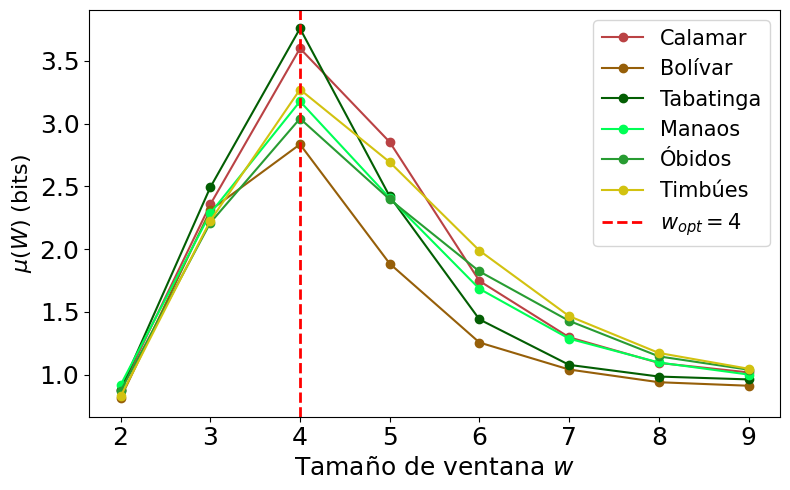

In [11]:
w_opts = optimizar_w_series(
    series=[serie_calamar, serie_bolivar, serie_tabatinga, serie_manaos, serie_obidos, serie_timbues],
    w_min=2,
    w_max=10,
    labels=[
        'Calamar', 'Bolívar', 'Tabatinga',
        'Manaos', 'Óbidos', 'Timbúes'
    ],
    colores=[
        '#ba4244', '#965f09', '#035e03',
        '#00ff55', '#289c32', '#d2c210'
    ]
)

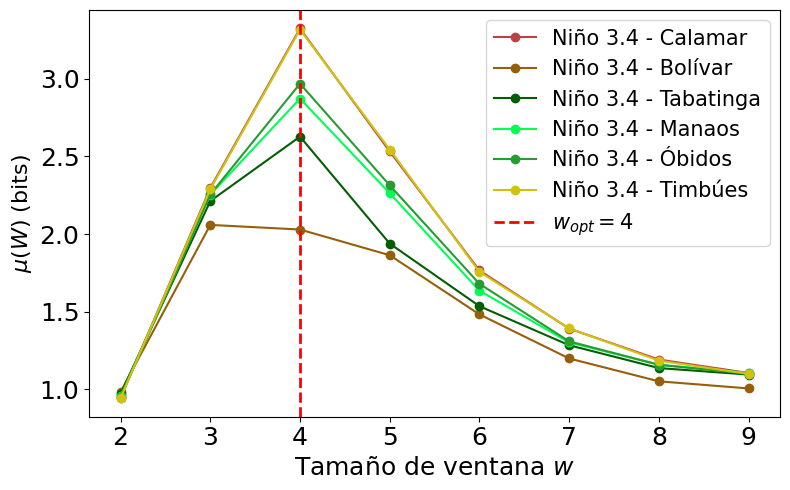

In [12]:
w_opts = optimizar_w_series(
    series=[serie_niño_calamar, serie_niño_bolivar, serie_niño_tabatinga, serie_niño_manaos, serie_niño_obidos, serie_niño_timbues],
    w_min=2,
    w_max=10,
    labels=[
        'Niño 3.4 - Calamar', 'Niño 3.4 - Bolívar', 'Niño 3.4 - Tabatinga',
        'Niño 3.4 - Manaos', 'Niño 3.4 - Óbidos', 'Niño 3.4 - Timbúes'
    ],
    colores=[
        '#ba4244', '#965f09', '#035e03',
        '#00ff55', '#289c32', '#d2c210'
    ]
)

DISTRIBUCIÓN

In [13]:
def plot_best_distribution_bootstrap(
    data,
    label="X",
    bins=22,
    log_transform=False,
    color="tab:blue",
    n_boot=300,
    save_path=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as ticker
    from scipy.stats import (
        norm, gamma, logistic, lognorm,
        weibull_min, expon, betaprime, skew
    )

    # ==============================
    # LIMPIEZA
    # ==============================
    data = np.array(data)
    data = data[np.isfinite(data)]

    if log_transform:
        data = data[data > 0]
        data = np.log10(data)
        xlabel = rf'$log_{{10}}({label})$'
    else:
        xlabel = label

    n = len(data)

    # ==============================
    # BOOTSTRAP
    # ==============================
    means, vars_, skews = [], [], []

    AICs = {
        "Normal": [],
        "Gamma": [],
        "Logística": [],
        "Lognormal": [],
        "Weibull": [],
        "Exponencial": [],
        "Betaprime": []
    }

    for _ in range(n_boot):
        sample = np.random.choice(data, size=n, replace=True)

        means.append(np.mean(sample))
        vars_.append(np.var(sample))
        skews.append(skew(sample))

        # Normal
        p = norm.fit(sample)
        AICs["Normal"].append(2*2 - 2*np.sum(norm.logpdf(sample, *p)))

        # Gamma
        p = gamma.fit(sample)
        AICs["Gamma"].append(2*3 - 2*np.sum(gamma.logpdf(sample, *p)))

        # Logística
        p = logistic.fit(sample)
        AICs["Logística"].append(2*2 - 2*np.sum(logistic.logpdf(sample, *p)))

        # Lognormal
        p = lognorm.fit(sample)
        AICs["Lognormal"].append(2*3 - 2*np.sum(lognorm.logpdf(sample, *p)))

        # Weibull
        p = weibull_min.fit(sample)
        AICs["Weibull"].append(2*3 - 2*np.sum(weibull_min.logpdf(sample, *p)))

        # Exponencial
        p = expon.fit(sample)
        AICs["Exponencial"].append(2*2 - 2*np.sum(expon.logpdf(sample, *p)))

        # Betaprime
        p = betaprime.fit(sample)
        AICs["Betaprime"].append(2*4 - 2*np.sum(betaprime.logpdf(sample, *p)))

    # ==============================
    # RESULTADOS BOOTSTRAP
    # ==============================
    mean = np.mean(means)
    var = np.mean(vars_)
    skewness = np.mean(skews)

    mean_ci = np.percentile(means, [2.5, 97.5])
    var_ci = np.percentile(vars_, [2.5, 97.5])
    skew_ci = np.percentile(skews, [2.5, 97.5])

    # ==============================
    # MEJOR MODELO
    # ==============================
    avg_AIC = {k: np.mean(v) for k, v in AICs.items()}
    best_name = min(avg_AIC, key=avg_AIC.get)

    if best_name == "Normal":
        dist, params = norm, norm.fit(data)
    elif best_name == "Gamma":
        dist, params = gamma, gamma.fit(data)
    elif best_name == "Logística":
        dist, params = logistic, logistic.fit(data)
    elif best_name == "Lognormal":
        dist, params = lognorm, lognorm.fit(data)
    elif best_name == "Weibull":
        dist, params = weibull_min, weibull_min.fit(data)
    elif best_name == "Exponencial":
        dist, params = expon, expon.fit(data)
    else:
        dist, params = betaprime, betaprime.fit(data)

    # ==============================
    # PLOT
    # ==============================
    x = np.linspace(data.min(), data.max(), 1000)
    pdf = dist.pdf(x, *params)

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(7, 5))

    sns.histplot(data, bins=bins, stat="density",
                 color=color, alpha=0.6, ax=ax)

    ax.plot(x, pdf, color=color, linewidth=2.5,
            label=f"{best_name}")

    # TEXTO
    textstr = (
        f"μ = {mean:.2f} [{mean_ci[0]:.2f}, {mean_ci[1]:.2f}]\n"
        f"σ² = {var:.2f} [{var_ci[0]:.2f}, {var_ci[1]:.2f}]\n"
        f"sk = {skewness:.2f} [{skew_ci[0]:.2f}, {skew_ci[1]:.2f}]"
    )

    ax.text(
        0.97, 0.97, textstr,
        transform=ax.transAxes,
        ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    ax.grid(False)
    plt.show()

    return {
        "best_distribution": best_name,
        "mean": mean,
        "variance": var,
        "skewness": skewness,
        "AIC": avg_AIC
    }

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


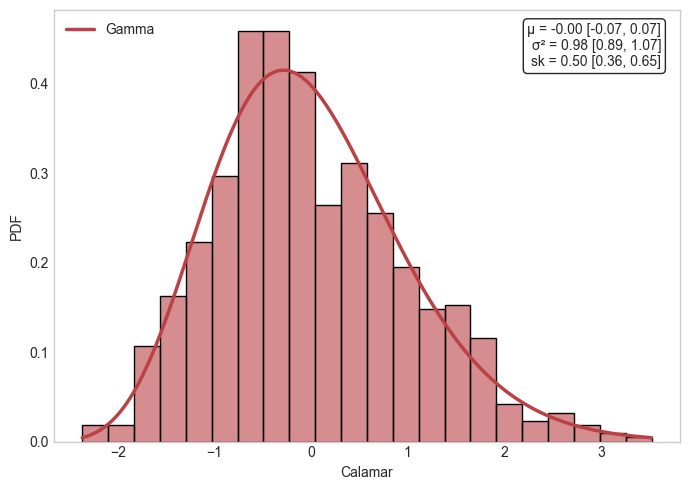

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


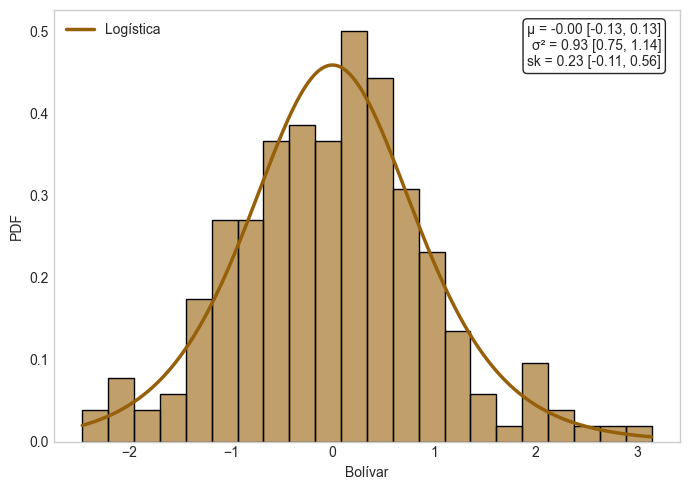

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


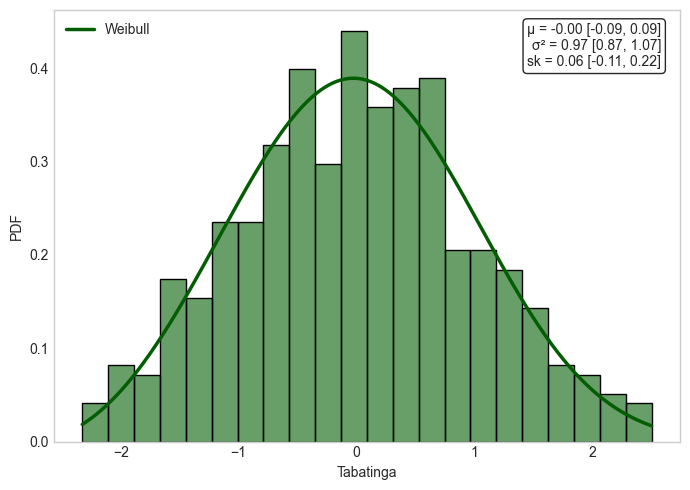

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


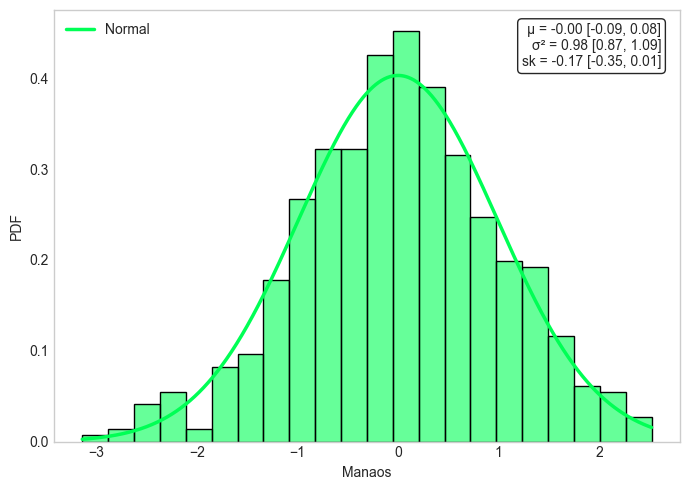

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


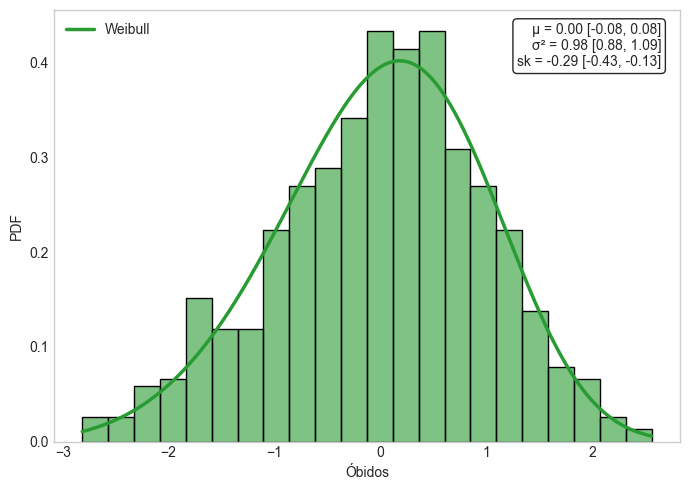

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


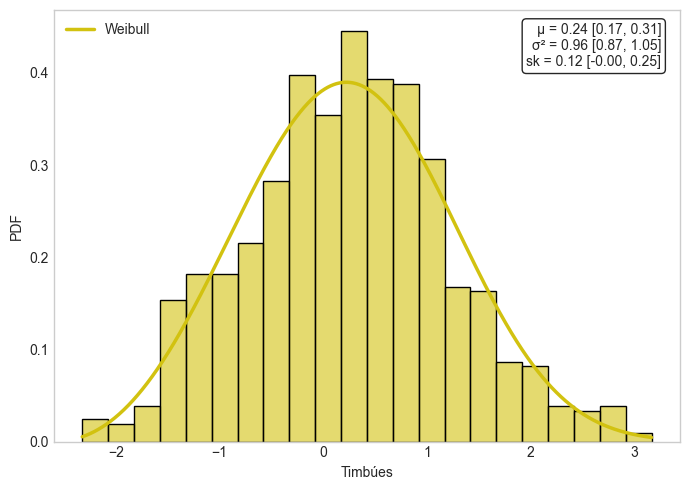

{'best_distribution': 'Weibull',
 'mean': np.float64(0.24257924755047935),
 'variance': np.float64(0.9574415338596949),
 'skewness': np.float64(0.12043794134526163),
 'AIC': {'Normal': np.float64(2336.2766406592223),
  'Gamma': np.float64(2335.2689544804143),
  'Logística': np.float64(2354.239584397342),
  'Lognormal': np.float64(2335.363826204885),
  'Weibull': np.float64(2331.6350476311973),
  'Exponencial': np.float64(3222.5414246524347),
  'Betaprime': np.float64(2382.372298166347)}}

In [14]:
plot_best_distribution_bootstrap(
    serie_calamar,
    label="Calamar",
    log_transform=False,
    color="#ba4244",
    n_boot=500
)
plot_best_distribution_bootstrap(
    serie_bolivar,
    label="Bolívar",
    log_transform=False,
    color="#965f09",
    n_boot=500
)
plot_best_distribution_bootstrap(
    serie_tabatinga,
    label="Tabatinga",
    log_transform=False,
    color="#035e03",
    n_boot=500
)
plot_best_distribution_bootstrap(
    serie_manaos,
    label="Manaos",
    log_transform=False,
    color="#00ff55",
    n_boot=500
)
plot_best_distribution_bootstrap(
    serie_obidos,
    label="Óbidos",
    log_transform=False,
    color="#289c32",
    n_boot=500
)
plot_best_distribution_bootstrap(
    serie_timbues,
    label="Timbúes",
    log_transform=False,
    color="#d2c210",
    n_boot=500
)

In [15]:
def plot_multiple_distributions_bootstrap(
    data_list,
    labels,
    colors,
    bins=22,
    log_transform=False,
    n_boot=300,
    save_path=None
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.ticker as ticker
    from scipy.stats import (
        norm, gamma, logistic, lognorm,
        weibull_min, expon, betaprime, skew
    )

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(8, 5))

    results = {}

    for data, label, color in zip(data_list, labels, colors):

        data = np.array(data)
        data = data[np.isfinite(data)]

        if log_transform:
            data = data[data > 0]
            data = np.log10(data)
            xlabel = rf'$log_{{10}}({label})$'
        else:
            xlabel = "Valor"

        n = len(data)

        # ==============================
        # BOOTSTRAP + AIC
        # ==============================
        AICs = {
            "Normal": [],
            "Gamma": [],
            "Logística": [],
            "Lognormal": [],
            "Weibull": [],
            "Exponencial": [],
            "Betaprime": []
        }

        means, vars_, skews = [], [], []

        for _ in range(n_boot):
            sample = np.random.choice(data, size=n, replace=True)

            means.append(np.mean(sample))
            vars_.append(np.var(sample))
            skews.append(skew(sample))

            # Normal
            p = norm.fit(sample)
            AICs["Normal"].append(2*2 - 2*np.sum(norm.logpdf(sample, *p)))

            # Gamma
            p = gamma.fit(sample)
            AICs["Gamma"].append(2*3 - 2*np.sum(gamma.logpdf(sample, *p)))

            # Logística
            p = logistic.fit(sample)
            AICs["Logística"].append(2*2 - 2*np.sum(logistic.logpdf(sample, *p)))

            # Lognormal
            p = lognorm.fit(sample)
            AICs["Lognormal"].append(2*3 - 2*np.sum(lognorm.logpdf(sample, *p)))

            # Weibull
            p = weibull_min.fit(sample)
            AICs["Weibull"].append(2*3 - 2*np.sum(weibull_min.logpdf(sample, *p)))

            # Exponencial
            p = expon.fit(sample)
            AICs["Exponencial"].append(2*2 - 2*np.sum(expon.logpdf(sample, *p)))

            # Betaprime
            p = betaprime.fit(sample)
            AICs["Betaprime"].append(2*4 - 2*np.sum(betaprime.logpdf(sample, *p)))

        # ==============================
        # MEJOR MODELO
        # ==============================
        avg_AIC = {k: np.mean(v) for k, v in AICs.items()}
        best_name = min(avg_AIC, key=avg_AIC.get)

        if best_name == "Normal":
            dist, params = norm, norm.fit(data)
        elif best_name == "Gamma":
            dist, params = gamma, gamma.fit(data)
        elif best_name == "Logística":
            dist, params = logistic, logistic.fit(data)
        elif best_name == "Lognormal":
            dist, params = lognorm, lognorm.fit(data)
        elif best_name == "Weibull":
            dist, params = weibull_min, weibull_min.fit(data)
        elif best_name == "Exponencial":
            dist, params = expon, expon.fit(data)
        else:
            dist, params = betaprime, betaprime.fit(data)

        x = np.linspace(data.min(), data.max(), 1000)
        pdf = dist.pdf(x, *params)

        # ==============================
        # PLOT
        # ==============================
        sns.histplot(data, bins=bins, stat="density",
                     color=color, alpha=0.25, ax=ax)

        ax.plot(x, pdf, color=color, linewidth=2.5,
                label=f"{label} ({best_name})")

        results[label] = {
            "best": best_name,
            "mean": np.mean(means),
            "var": np.mean(vars_),
            "skew": np.mean(skews)
        }

    ax.set_xlabel(xlabel)
    ax.set_ylabel("PDF")

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    ax.legend(frameon=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

    return results

/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)
/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)
/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


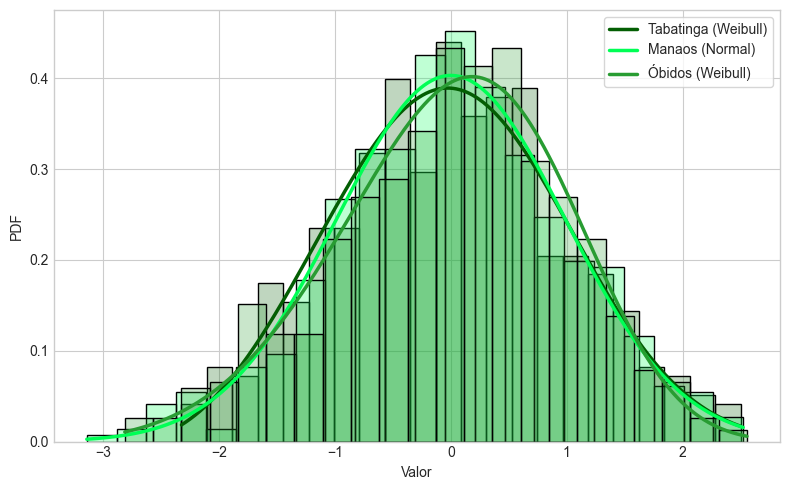

{'Tabatinga': {'best': 'Weibull',
  'mean': np.float64(-0.00483849488304759),
  'var': np.float64(0.9685733771338751),
  'skew': np.float64(0.06918434363846616)},
 'Manaos': {'best': 'Normal',
  'mean': np.float64(-0.0006382387965259375),
  'var': np.float64(0.9778415510912828),
  'skew': np.float64(-0.1767331078301452)},
 'Óbidos': {'best': 'Weibull',
  'mean': np.float64(0.002156869272521559),
  'var': np.float64(0.9737784894963909),
  'skew': np.float64(-0.284778836026843)}}

In [16]:
plot_multiple_distributions_bootstrap(
    [serie_tabatinga, serie_manaos, serie_obidos],
    labels=["Tabatinga", "Manaos", "Óbidos"],
    colors=["#035e03", "#00ff55", "#289c32"],
    log_transform=False
)